# Unsupervised Learning: Trade & Ahead

## Problem Statement

### Context

The stock market has consistently proven to be a good place to invest in and save for the future. There are a lot of compelling reasons to invest in stocks. It can help in fighting inflation, create wealth, and also provides some tax benefits. Good steady returns on investments over a long period of time can also grow a lot more than seems possible. Also, thanks to the power of compound interest, the earlier one starts investing, the larger the corpus one can have for retirement. Overall, investing in stocks can help meet life's financial aspirations.

It is important to maintain a diversified portfolio when investing in stocks in order to maximise earnings under any market condition. Having a diversified portfolio tends to yield higher returns and face lower risk by tempering potential losses when the market is down. It is often easy to get lost in a sea of financial metrics to analyze while determining the worth of a stock, and doing the same for a multitude of stocks to identify the right picks for an individual can be a tedious task. By doing a cluster analysis, one can identify stocks that exhibit similar characteristics and ones which exhibit minimum correlation. This will help investors better analyze stocks across different market segments and help protect against risks that could make the portfolio vulnerable to losses.


### Objective

Trade&Ahead is a financial consultancy firm who provide their customers with personalized investment strategies. They have hired you as a Data Scientist and provided you with data comprising stock price and some financial indicators for a few companies listed under the New York Stock Exchange. They have assigned you the tasks of analyzing the data, grouping the stocks based on the attributes provided, and sharing insights about the characteristics of each group.

### Data Dictionary

- Ticker Symbol: An abbreviation used to uniquely identify publicly traded shares of a particular stock on a particular stock market
- Company: Name of the company
- GICS Sector: The specific economic sector assigned to a company by the Global Industry Classification Standard (GICS) that best defines its business operations
- GICS Sub Industry: The specific sub-industry group assigned to a company by the Global Industry Classification Standard (GICS) that best defines its business operations
- Current Price: Current stock price in dollars
- Price Change: Percentage change in the stock price in 13 weeks
- Volatility: Standard deviation of the stock price over the past 13 weeks
- ROE: A measure of financial performance calculated by dividing net income by shareholders' equity (shareholders' equity is equal to a company's assets minus its debt)
- Cash Ratio: The ratio of a  company's total reserves of cash and cash equivalents to its total current liabilities
- Net Cash Flow: The difference between a company's cash inflows and outflows (in dollars)
- Net Income: Revenues minus expenses, interest, and taxes (in dollars)
- Earnings Per Share: Company's net profit divided by the number of common shares it has outstanding (in dollars)
- Estimated Shares Outstanding: Company's stock currently held by all its shareholders
- P/E Ratio: Ratio of the company's current stock price to the earnings per share
- P/B Ratio: Ratio of the company's stock price per share by its book value per share (book value of a company is the net difference between that company's total assets and total liabilities)

## Importing necessary libraries and data

In [ ]:
# Installing the libraries with the specified version.
!pip install scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==1.5.3 yellowbrick==1.5 -q --user

In [ ]:
# Installing the libraries with the specified version.
# uncomment and run the following lines if Jupyter Notebook is being used
# !pip install scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==1.5.2 yellowbrick==1.5 -q --user
# !pip install --upgrade -q jinja2

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [ ]:
# libraries for data manipulation
import numpy as np
import pandas as pd

# libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# libraries for data scaling
from sklearn.preprocessing import StandardScaler

# libraries for distance computing
from scipy.spatial.distance import cdist, pdist

# libraries for k-means clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# libraries for hierarchical clustering
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet

# libraries for visualization of elbow curve and silhouette scores
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

In [ ]:
# removes column limit
pd.set_option('display.max_columns', None)

# sets row limit
pd.set_option('display.max_rows', 200)

In [ ]:
import warnings
warnings.filterwarnings('ignore')

## Loading the dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Datasets/stock_data.csv")
df = data.copy()

## Data Overview

- Observations
- Sanity checks

### Dimensions of the data

In [ ]:
# displays the dimensions of the data
df.shape

(340, 15)

### First five rows

In [ ]:
# displays the first five rows
df.head()

,Ticker Symbol,Security,GICS Sector,GICS Sub Industry,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
0,AAL,American Airlines Group,Industrials,Airlines,42.349998,9.999995,1.687151,135,51,-604000000,7610000000,11.39,6.681299e+08,3.718174,-8.784219
1,ABBV,AbbVie,Health Care,Pharmaceuticals,59.240002,8.339433,2.197887,130,77,51000000,5144000000,3.15,1.633016e+09,18.806350,-8.750068
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,44.910000,11.301121,1.273646,21,67,938000000,4423000000,2.94,1.504422e+09,15.275510,-0.394171
3,ADBE,Adobe Systems Inc,Information Technology,Application Software,93.940002,13.977195,1.357679,9,180,-240840000,629551000,1.26,4.996437e+08,74.555557,4.199651
4,ADI,"Analog Devices, Inc.",Information Technology,Semiconductors,55.320000,-1.827858,1.701169,14,272,315120000,696878000,0.31,2.247994e+09,178.451613,1.059810


### Last five rows

In [ ]:
# displays the last five rows
df.tail()

,Ticker Symbol,Security,GICS Sector,GICS Sub Industry,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
335,YHOO,Yahoo Inc.,Information Technology,Internet Software & Services,33.259998,14.887727,1.845149,15,459,-1032187000,-4359082000,-4.64,939457327.6,28.976191,6.261775
336,YUM,Yum! Brands Inc,Consumer Discretionary,Restaurants,52.516175,-8.698917,1.478877,142,27,159000000,1293000000,2.97,435353535.4,17.682214,-3.838260
337,ZBH,Zimmer Biomet Holdings,Health Care,Health Care Equipment,102.589996,9.347683,1.404206,1,100,376000000,147000000,0.78,188461538.5,131.525636,-23.884449
338,ZION,Zions Bancorp,Financials,Regional Banks,27.299999,-1.158588,1.468176,4,99,-43623000,309471000,1.20,257892500.0,22.749999,-0.063096
339,ZTS,Zoetis,Health Care,Pharmaceuticals,47.919998,16.678836,1.610285,32,65,272000000,339000000,0.68,498529411.8,70.470585,1.723068


### Datatypes

In [ ]:
# displays datatypes and non-null count
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340 entries, 0 to 339
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticker Symbol                 340 non-null    object 
 1   Security                      340 non-null    object 
 2   GICS Sector                   340 non-null    object 
 3   GICS Sub Industry             340 non-null    object 
 4   Current Price                 340 non-null    float64
 5   Price Change                  340 non-null    float64
 6   Volatility                    340 non-null    float64
 7   ROE                           340 non-null    int64  
 8   Cash Ratio                    340 non-null    int64  
 9   Net Cash Flow                 340 non-null    int64  
 10  Net Income                    340 non-null    int64  
 11  Earnings Per Share            340 non-null    float64
 12  Estimated Shares Outstanding  340 non-null    float64
 13  P/E R

### Missing values

In [ ]:
# returns the sum of null value counts
df.isna().sum()

,0
Ticker Symbol,0
Security,0
GICS Sector,0
GICS Sub Industry,0
Current Price,0
Price Change,0
Volatility,0
ROE,0
Cash Ratio,0
Net Cash Flow,0


### Duplicate values

In [ ]:
# returns the sum of duplicate value counts
df.duplicated().sum()

np.int64(0)

### Statistical Summary

In [ ]:
# displays statistical summary of numeric data
df.describe(include=np.number).T

,count,mean,std,min,25%,50%,75%,max
Current Price,340.0,8.086234e+01,9.805509e+01,4.500000e+00,3.855500e+01,5.970500e+01,9.288000e+01,1.274950e+03
Price Change,340.0,4.078194e+00,1.200634e+01,-4.712969e+01,-9.394838e-01,4.819505e+00,1.069549e+01,5.505168e+01
Volatility,340.0,1.525976e+00,5.917984e-01,7.331632e-01,1.134878e+00,1.385593e+00,1.695549e+00,4.580042e+00
ROE,340.0,3.959706e+01,9.654754e+01,1.000000e+00,9.750000e+00,1.500000e+01,2.700000e+01,9.170000e+02
Cash Ratio,340.0,7.002353e+01,9.042133e+01,0.000000e+00,1.800000e+01,4.700000e+01,9.900000e+01,9.580000e+02
Net Cash Flow,340.0,5.553762e+07,1.946365e+09,-1.120800e+10,-1.939065e+08,2.098000e+06,1.698108e+08,2.076400e+10
Net Income,340.0,1.494385e+09,3.940150e+09,-2.352800e+10,3.523012e+08,7.073360e+08,1.899000e+09,2.444200e+10
Earnings Per Share,340.0,2.776662e+00,6.587779e+00,-6.120000e+01,1.557500e+00,2.895000e+00,4.620000e+00,5.009000e+01
Estimated Shares Outstanding,340.0,5.770283e+08,8.458496e+08,2.767216e+07,1.588482e+08,3.096751e+08,5.731175e+08,6.159292e+09
P/E Ratio,340.0,3.261256e+01,4.434873e+01,2.935451e+00,1.504465e+01,2.081988e+01,3.176476e+01,5.280391e+02


In [ ]:
# displays statistical summary of categorical data
df.describe(include=np.object_).T

,count,unique,top,freq
Ticker Symbol,340,340,ZTS,1
Security,340,340,Zoetis,1
GICS Sector,340,11,Industrials,53
GICS Sub Industry,340,104,Oil & Gas Exploration & Production,16


## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. What does the distribution of stock prices look like?
2. The stocks of which economic sector have seen the maximum price increase on average?
3. How are the different variables correlated with each other?
4. Cash ratio provides a measure of a company's ability to cover its short-term obligations using only cash and cash equivalents. How does the average cash ratio vary across economic sectors?
5. P/E ratios can help determine the relative value of a company's shares as they signify the amount of money an investor is willing to invest in a single share of a company per dollar of its earnings. How does the P/E ratio vary, on average, across economic sectors?

### Univariate Analysis

#### Custom Functions

In [ ]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        hue=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

#### GICS Sector

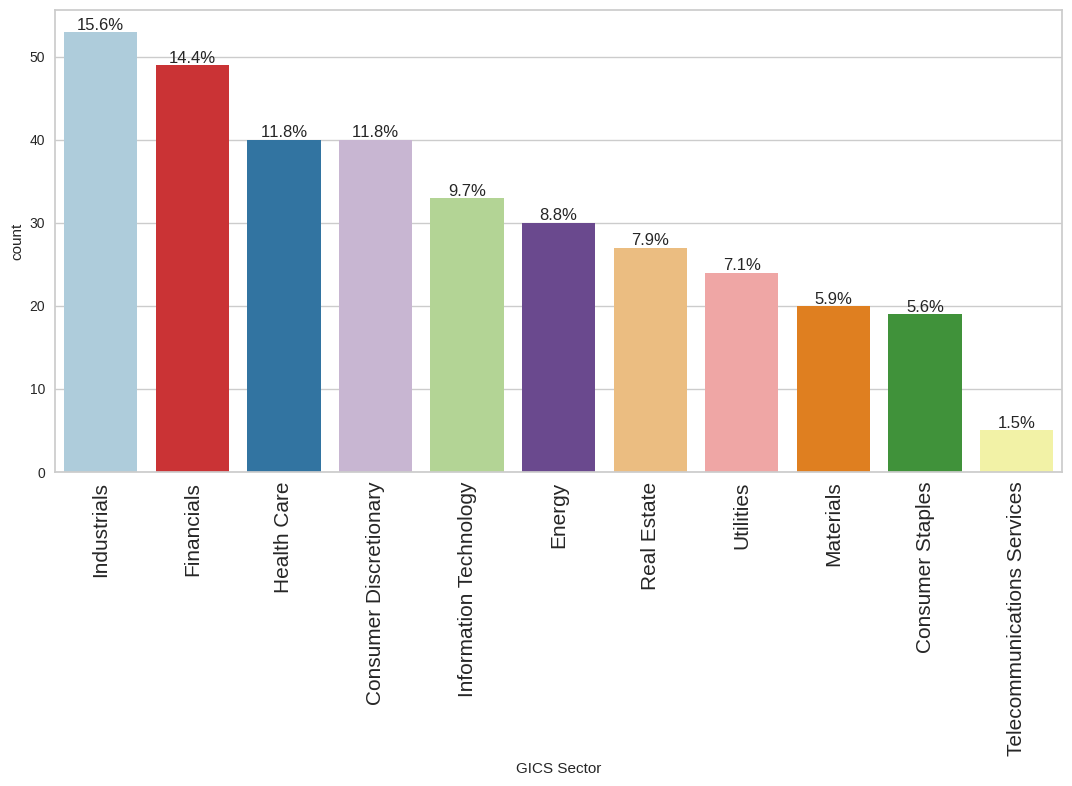

In [ ]:
labeled_barplot(df, 'GICS Sector', perc=True)

Observations: The most prevalent GICS sectors are: Industrials (15.6%), Financials (14.4%), and Healthcare (11.8%).

#### GICS Sub Industry

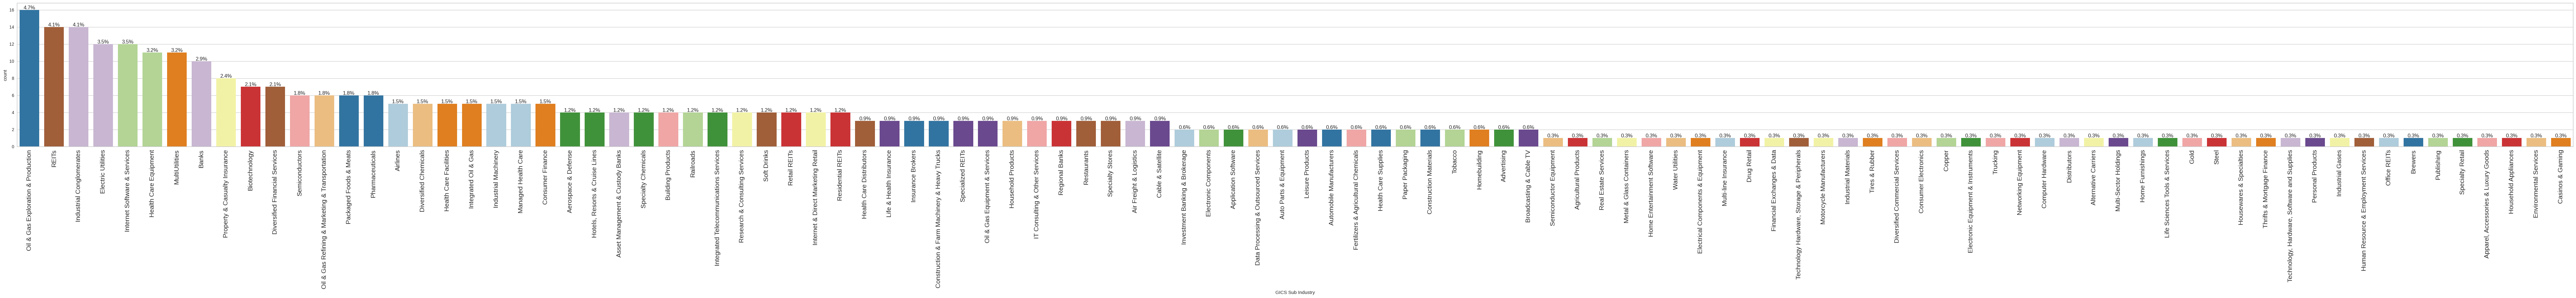

In [ ]:
labeled_barplot(df, 'GICS Sub Industry', perc=True)

In [ ]:
df['GICS Sub Industry'].value_counts()

,count
GICS Sub Industry,
Oil & Gas Exploration & Production,16
REITs,14
Industrial Conglomerates,14
Electric Utilities,12
Internet Software & Services,12
Health Care Equipment,11
MultiUtilities,11
Banks,10
Property & Casualty Insurance,8


Observations: The most prevalent GICS subindustries are Oil & Gas Exploration and Production, REITs, and Industrial Conglomerates.

#### Current Price

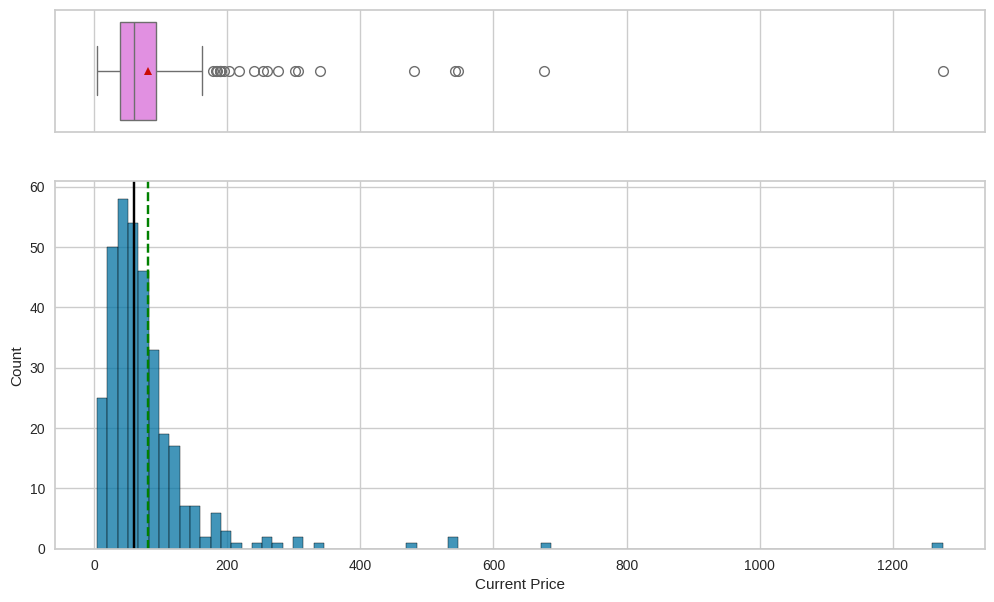

In [ ]:
histogram_boxplot(df, 'Current Price')

In [ ]:
df['Current Price'].describe()

,Current Price
count,340.000000
mean,80.862345
std,98.055086
min,4.500000
25%,38.555000
50%,59.705000
75%,92.880001
max,1274.949951


Observations: About 50% of current prices fall between \$38 and \$93. The average current price is about \$81. Current prices have a right-skewed distribution, indicating that there are expensive stocks.

#### Price Change

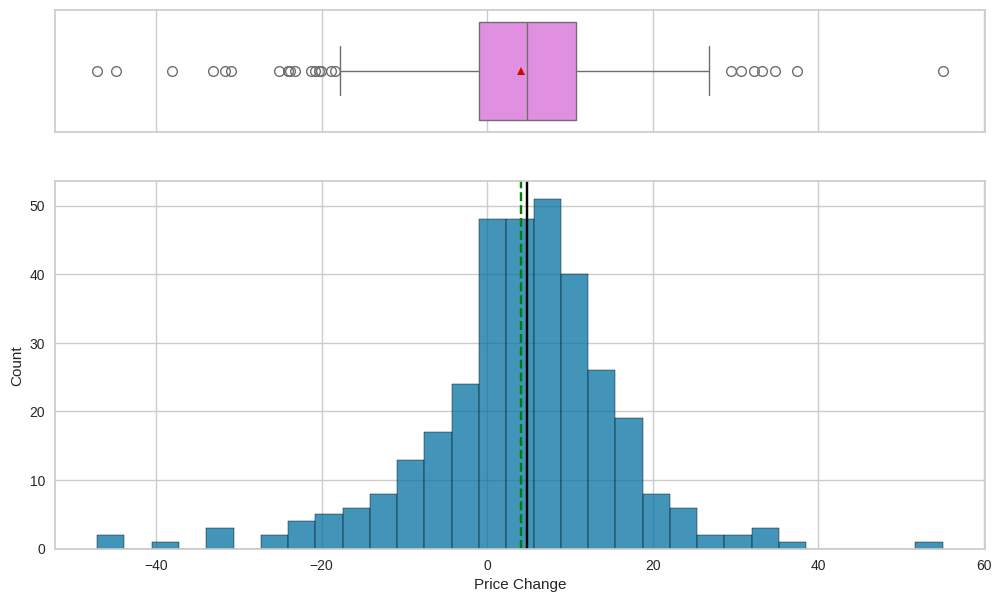

In [ ]:
histogram_boxplot(df, 'Price Change')

In [ ]:
df['Price Change'].describe()

,Price Change
count,340.000000
mean,4.078194
std,12.006338
min,-47.129693
25%,-0.939484
50%,4.819505
75%,10.695493
max,55.051683


Observations: About half of the price change data falls between -1% and 11%. The average price change is about 4%.

#### Volatility

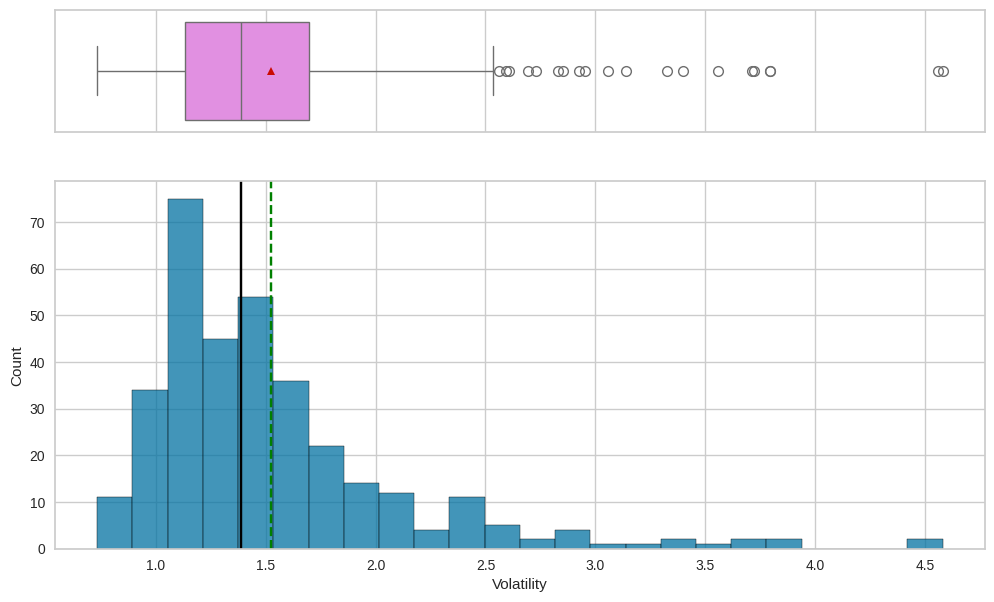

In [ ]:
histogram_boxplot(df, 'Volatility')

Observations: The majority of the volatility values range between 0.5 and ~2.5. The average volatility is 1.5, and 50% of values are greater or less than 1.4.

#### ROE

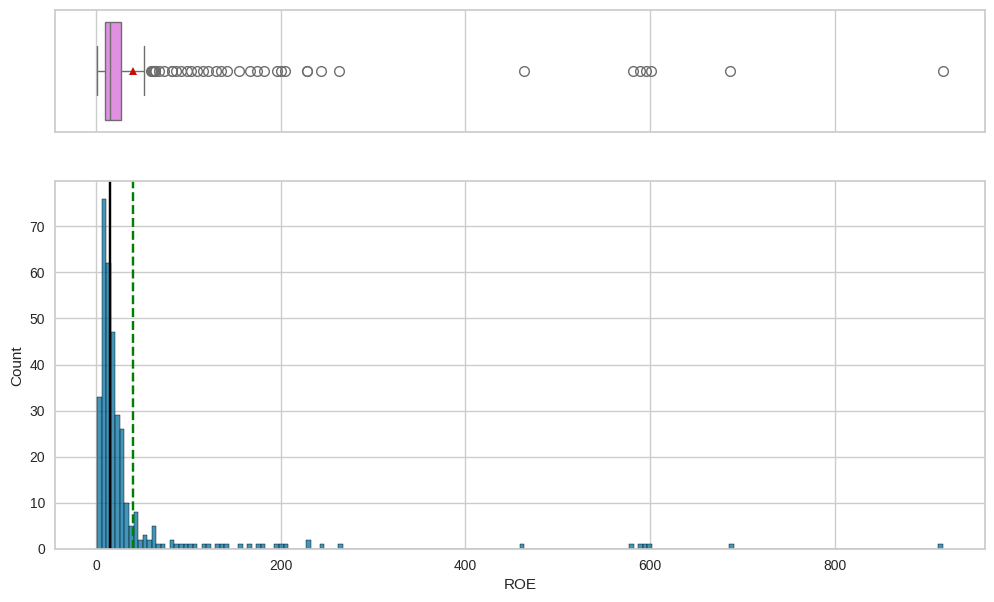

In [ ]:
histogram_boxplot(df, 'ROE')

In [ ]:
df['ROE'].describe()

,ROE
count,340.000000
mean,39.597059
std,96.547538
min,1.000000
25%,9.750000
50%,15.000000
75%,27.000000
max,917.000000


Observations: Majority of ROE falls between 0 and ~50. The average is 39.6 and the median is 15.

#### Cash Ratio

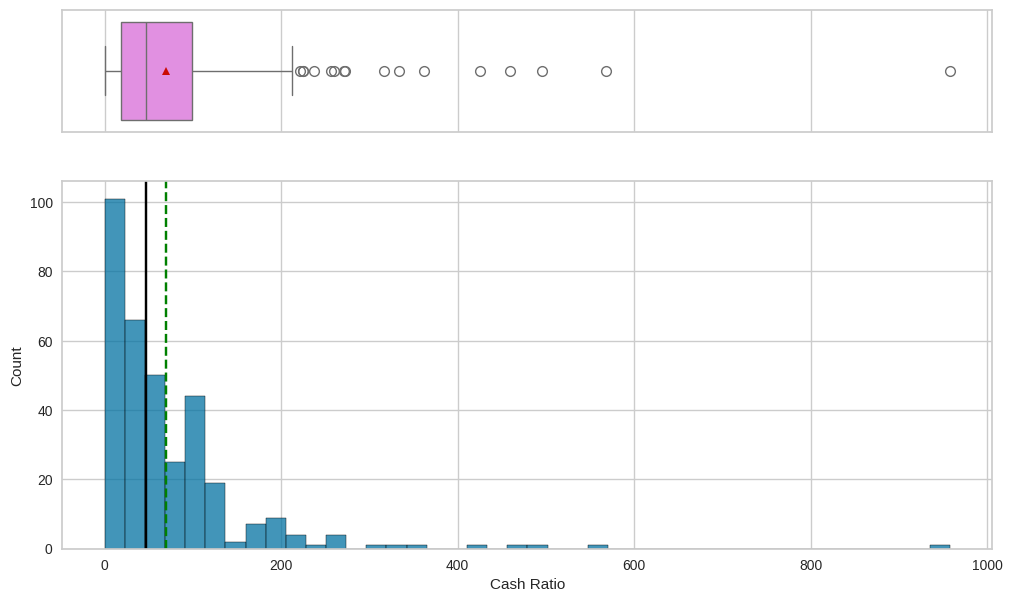

In [ ]:
histogram_boxplot(df, 'Cash Ratio')

In [ ]:
df['Cash Ratio'].describe()

,Cash Ratio
count,340.000000
mean,70.023529
std,90.421331
min,0.000000
25%,18.000000
50%,47.000000
75%,99.000000
max,958.000000


Observations: 50% of the cash ratio data falls between 18 and 99. The median ratio is 70 and the median is 47.

#### Net Cash Flow

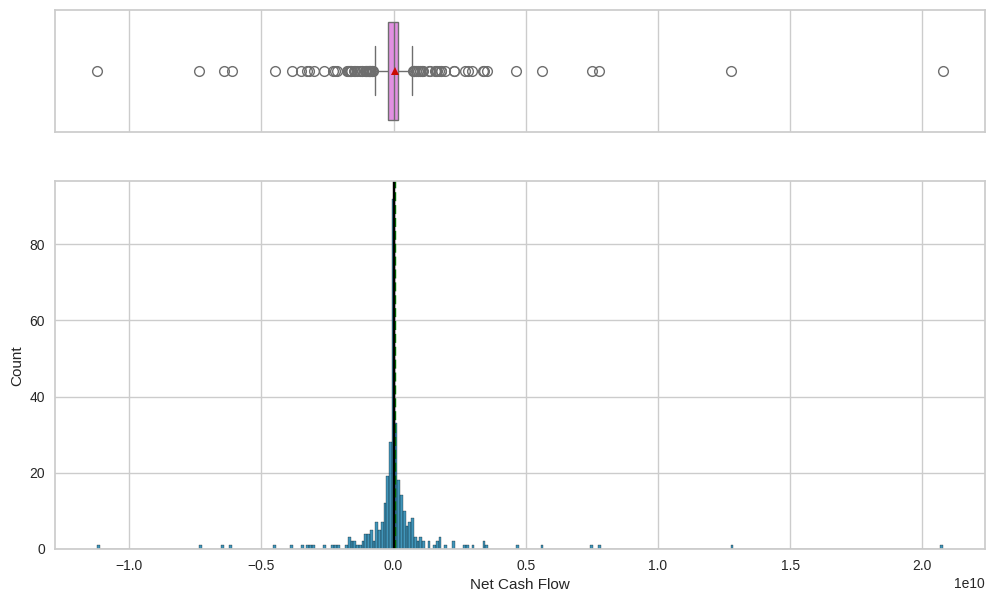

In [ ]:
histogram_boxplot(df, 'Net Cash Flow')

In [ ]:
df['Net Cash Flow'].describe()

,Net Cash Flow
count,3.400000e+02
mean,5.553762e+07
std,1.946365e+09
min,-1.120800e+10
25%,-1.939065e+08
50%,2.098000e+06
75%,1.698108e+08
max,2.076400e+10


Observations: About 50% of the data falls between -193,900,000 and 169,800,000. The mean net cash flow is around 55,530,000 and the median of the data is 2,098,000.

#### Net Income

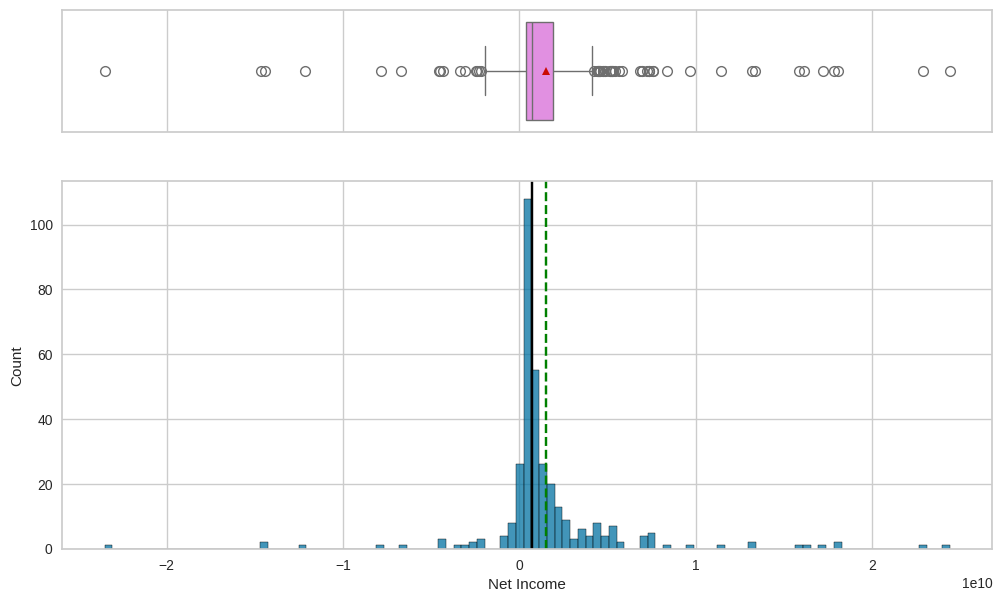

In [ ]:
histogram_boxplot(df, 'Net Income')

In [ ]:
df['Net Income'].describe()

,Net Income
count,3.400000e+02
mean,1.494385e+09
std,3.940150e+09
min,-2.352800e+10
25%,3.523012e+08
50%,7.073360e+08
75%,1.899000e+09
max,2.444200e+10


Observations: 50% of the net income data falls between 35,230,000 and 1,899,000,000. The average is 1,494,400,000 and the median is 707,340,000.

#### Earnings Per Share

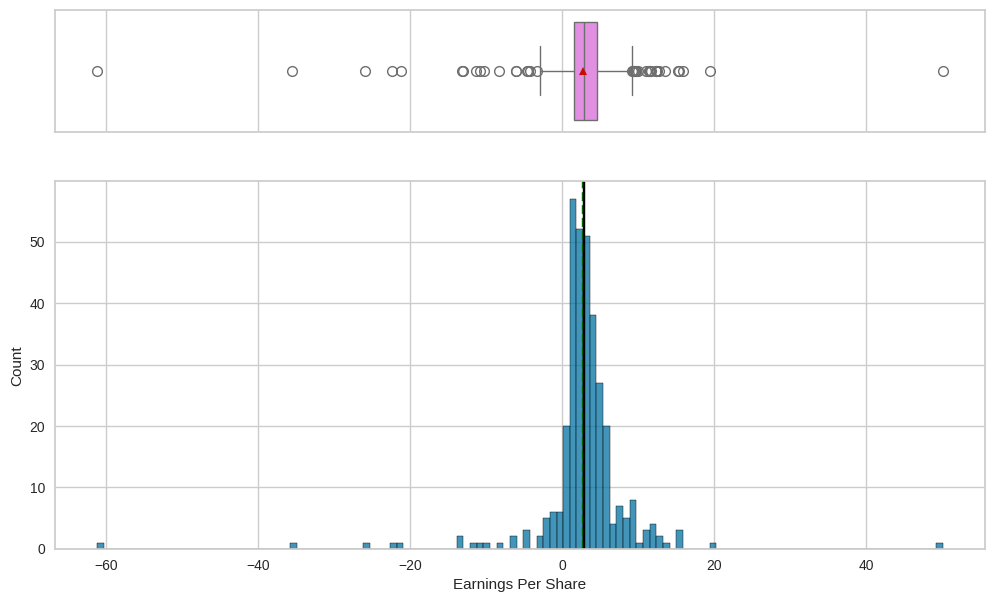

In [ ]:
histogram_boxplot(df, 'Earnings Per Share')

In [ ]:
df['Earnings Per Share'].describe()

,Earnings Per Share
count,340.000000
mean,2.776662
std,6.587779
min,-61.200000
25%,1.557500
50%,2.895000
75%,4.620000
max,50.090000


Observations: The interquartile range for earnings per share is from 1.5575 to 4.62. The average earning per share is ~2.777 and the median is 2.895.

#### Estimated Shares Outstanding

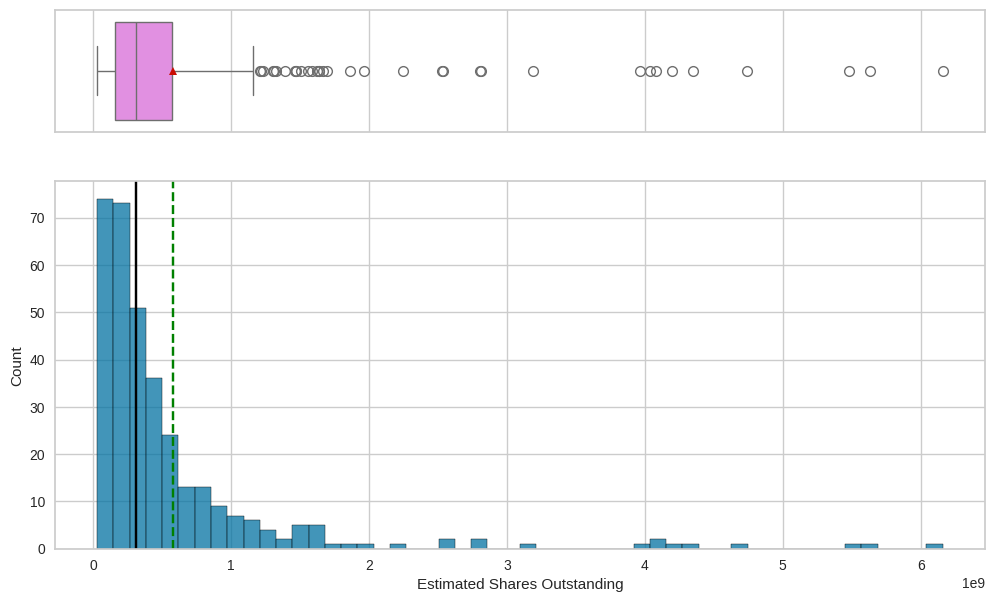

In [ ]:
histogram_boxplot(df, 'Estimated Shares Outstanding')

In [ ]:
df['Estimated Shares Outstanding'].describe()

,Estimated Shares Outstanding
count,3.400000e+02
mean,5.770283e+08
std,8.458496e+08
min,2.767216e+07
25%,1.588482e+08
50%,3.096751e+08
75%,5.731175e+08
max,6.159292e+09


Observations: 50% of the company stock held by all shareholders falls between 158,848,200 and 573,117,500. The mean is 577,028,300 and the median is 309,675,100.

#### P/E Ratio

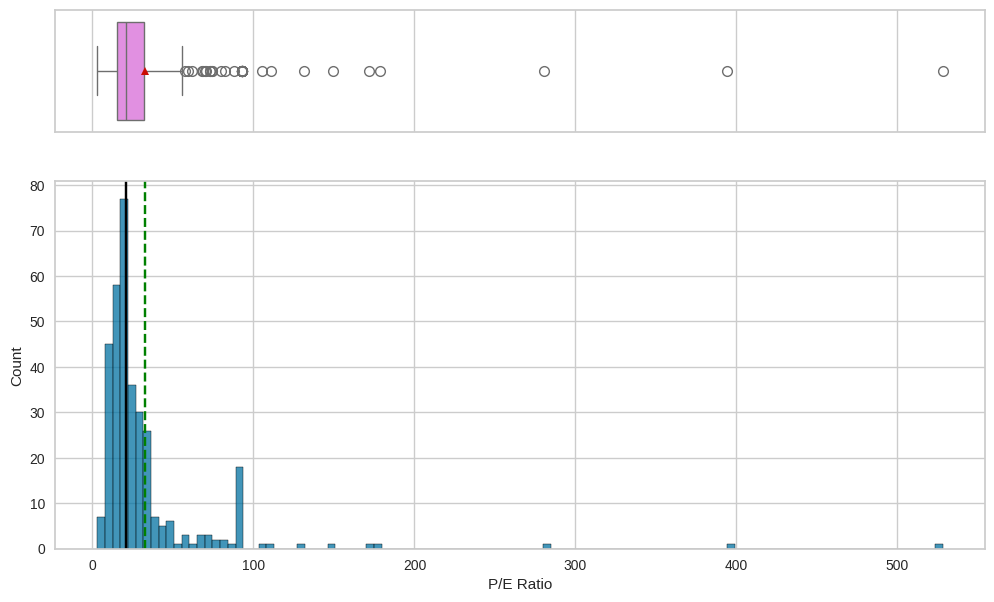

In [ ]:
histogram_boxplot(df, 'P/E Ratio')

In [ ]:
df['P/E Ratio'].describe()

,P/E Ratio
count,340.000000
mean,32.612563
std,44.348731
min,2.935451
25%,15.044653
50%,20.819876
75%,31.764755
max,528.039074


Observations: The IQR ranges from ~15 to ~32, the mean is ~32, and the median is ~21.

#### P/B Ratio

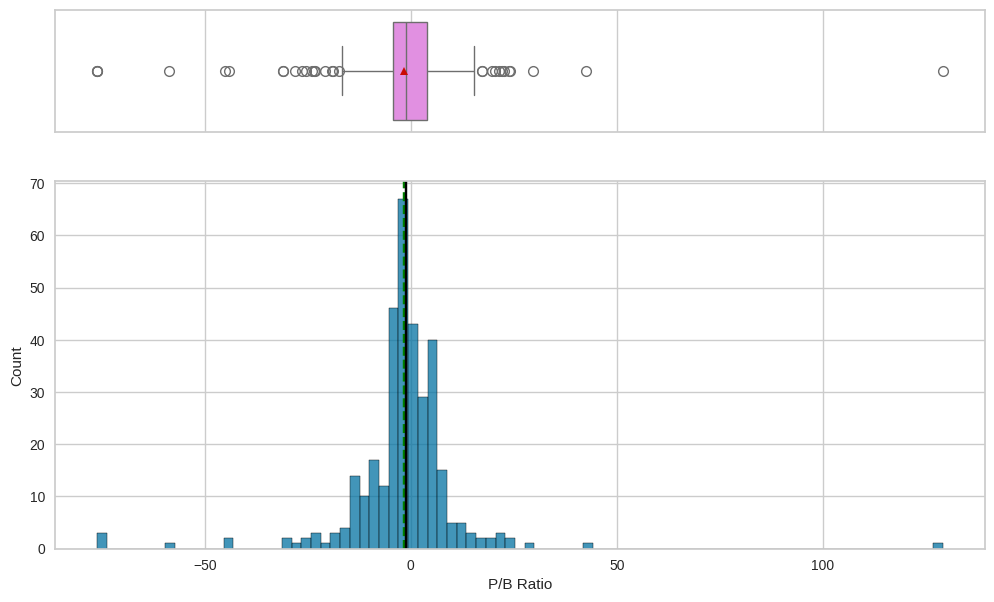

In [ ]:
histogram_boxplot(df, 'P/B Ratio')

In [ ]:
df['P/B Ratio'].describe()

,P/B Ratio
count,340.000000
mean,-1.718249
std,13.966912
min,-76.119077
25%,-4.352056
50%,-1.067170
75%,3.917066
max,129.064585


Observations: The IQR ranges from around -4.35 to ~3.92. The mean is about -1.72 and the median is about -1.07.

### Multivariate Analysis

#### Correlation Heatmap

<Axes: >

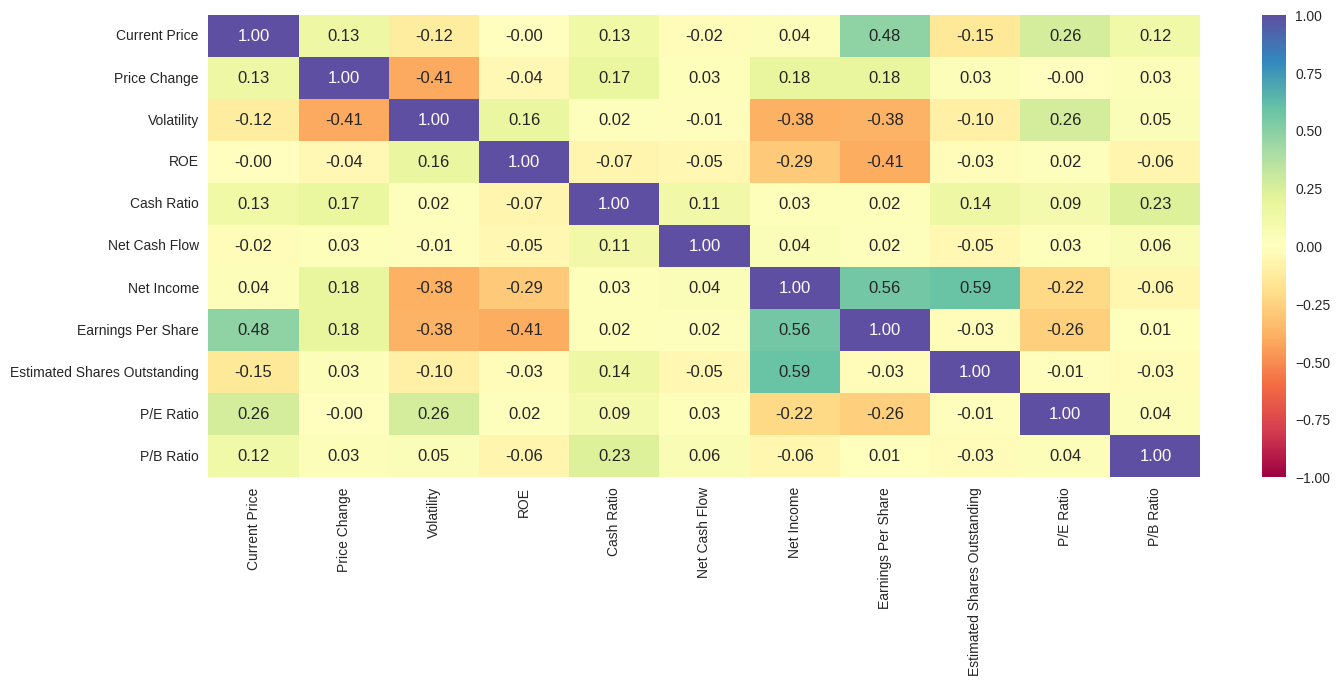

In [ ]:
cols = df.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(16, 6))
sns.heatmap(df[cols].corr(), annot=True, vmin=-1, vmax=1, fmt = ".2f", cmap="Spectral")

Observations:

There exists a moderate positive correlation between the following variables:

*   Net Income and Estimated Shares Outstanding (59%)
*   Net Income and Earnings Per Share (56%)
*   Current Price and Earnings Per Share (48%)

There exists a moderate negative correlation between the following variables:

*   Price Change and Volatility (-41%)
*   ROE and Earnings Per Share (-41%)


This makes sense, as Earnings Per Share is calculated using Net Income. Earnings Per Share is a good indicator of profitability and should influence the stocks' Current Price.

#### Economic Sector vs. Current Price

In [ ]:
#plt.figure(figsize=(18, 6))
#sns.boxplot(x='GICS Sector', y='Current Price', data=df)
#plt.show()

Will be ignoring outliers to better visualize data.

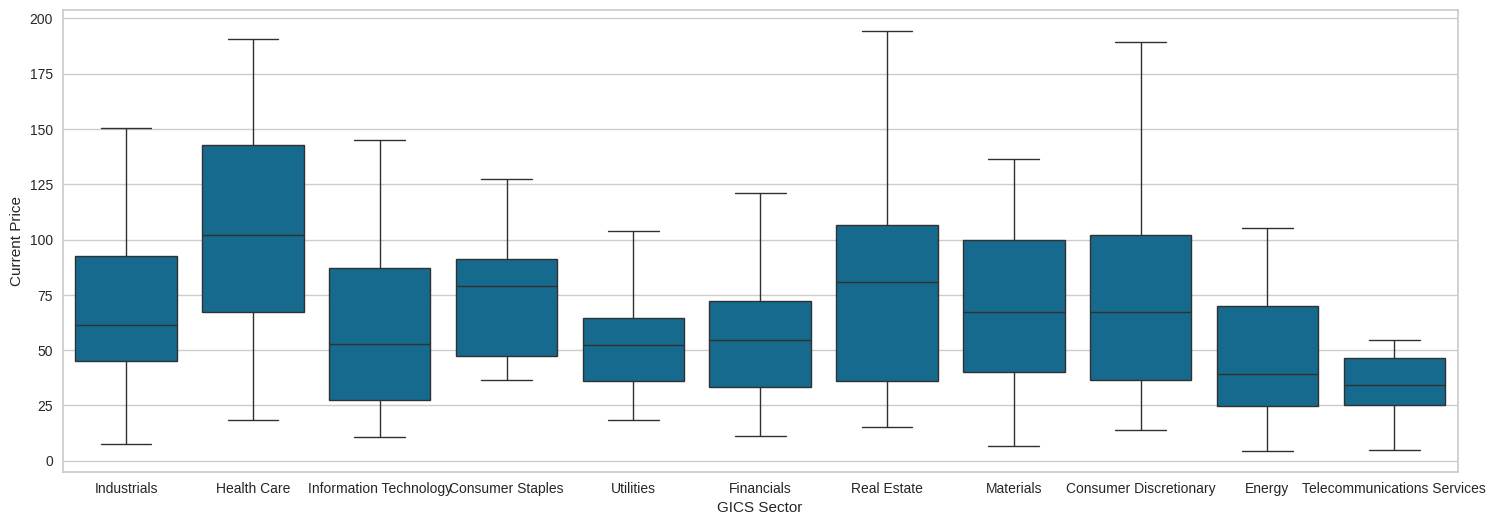

In [ ]:
# removes outliers to have a better look at the boxplots
plt.figure(figsize=(18, 6))
sns.boxplot(x='GICS Sector', y='Current Price', data=df, showfliers=False)
plt.show()

Observations: Health Care stocks have the highest price mean out of the economic sectors. This is followed by Real Estate and Consumer Staples. On the other hand, Telecommunication Services has the lowest price mean.

#### Economic Sector vs. Price Change

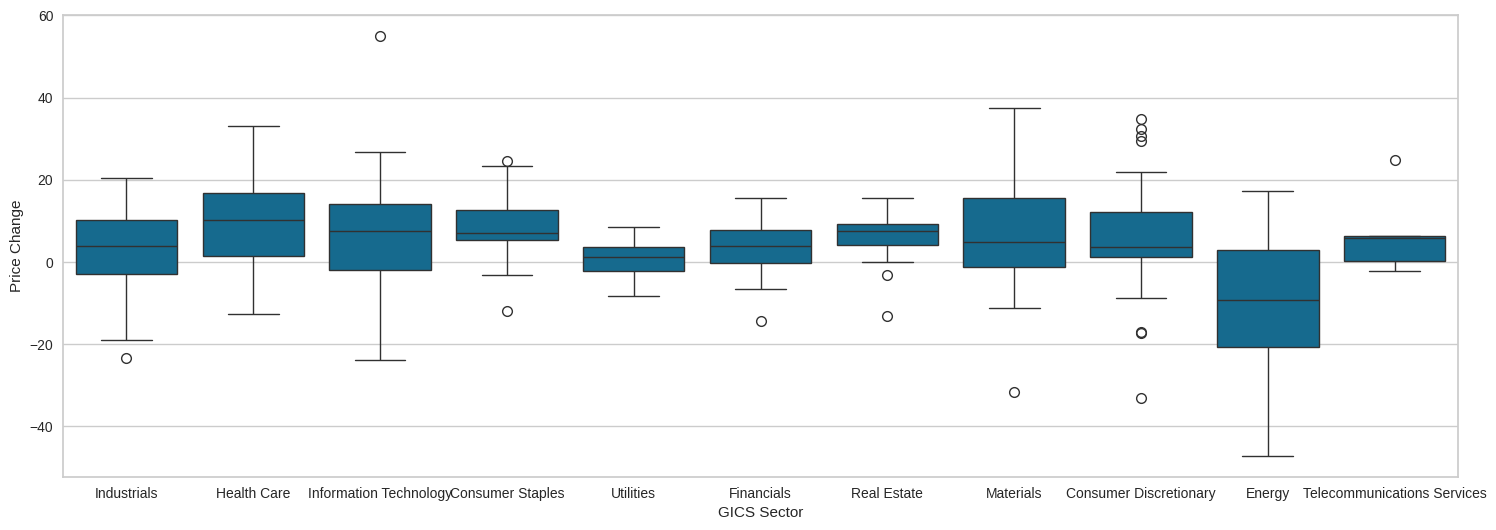

In [ ]:
plt.figure(figsize=(18, 6))
sns.boxplot(x='GICS Sector', y='Price Change', data=df)
plt.show()

Observations: Most economic sectors experienced price changes between -20% and 20%. It appears as if Health Care and Materials had the greatest price growth while the energy sector had the biggest price decline.

#### Economic Sector vs. Volatlity

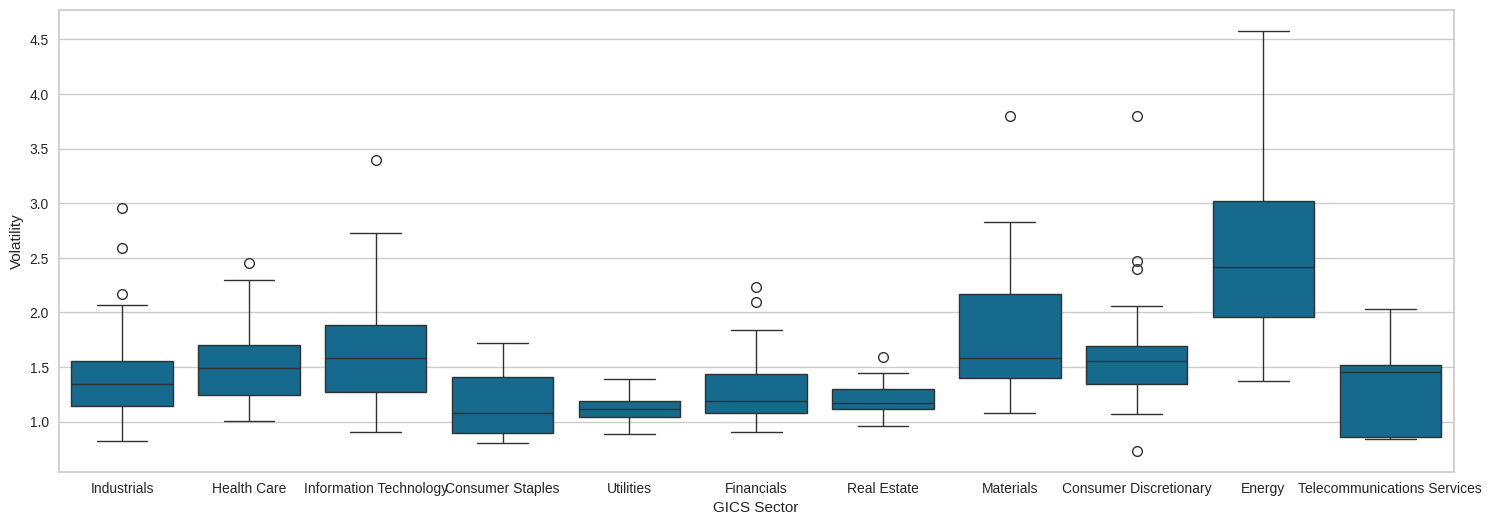

In [ ]:
plt.figure(figsize=(18, 6))
sns.boxplot(x='GICS Sector', y='Volatility', data=df)
plt.show()

Observations: The energy sector is the most volatile economic sector. This is followed by Materials and Information Technology. The rest of the economic sectors are not as volatile, ranging between 0.5 and 2.0.

####Economic Sector vs. ROE

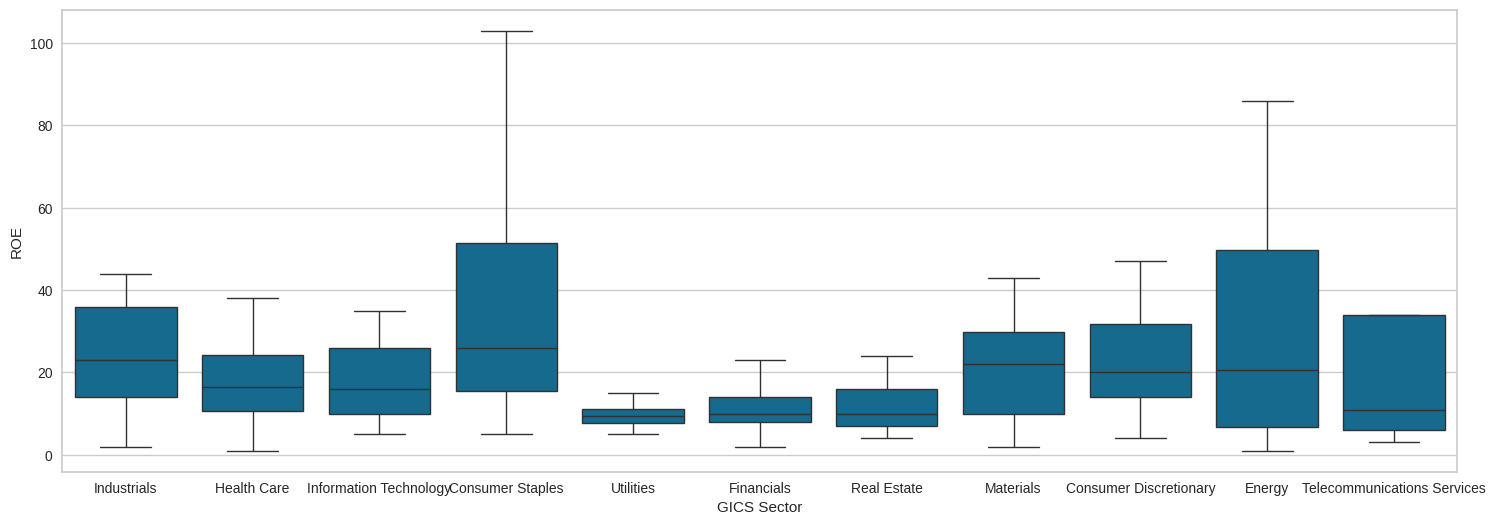

In [ ]:
# ignores outliers for better data visualization
plt.figure(figsize=(18, 6))
sns.boxplot(x='GICS Sector', y='ROE', data=df, showfliers=False)
plt.show()

Observations: The Consumer Staples and Energy sectors have the highest ranges of ROE. Utilities and Financials have the lowest ROE medians and have less variation than the other sectors.

####Economic Sector vs. Cash Ratio

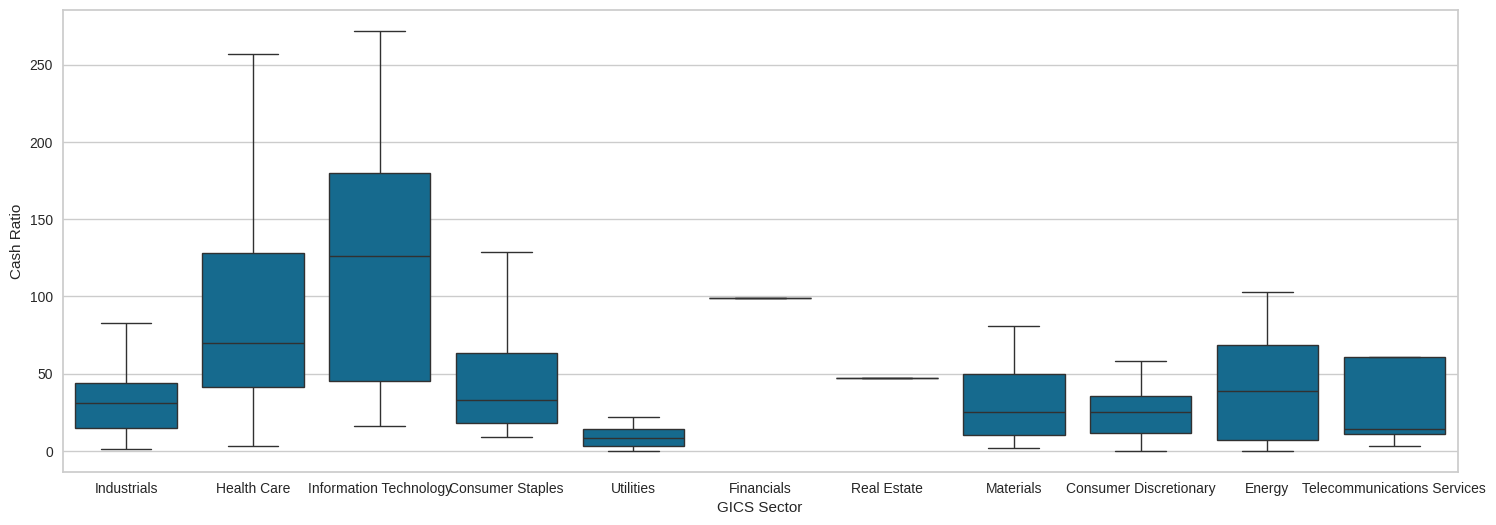

In [ ]:
# removes outliers for better data visualization
plt.figure(figsize=(18, 6))
sns.boxplot(x='GICS Sector', y='Cash Ratio', data=df, showfliers=False)
plt.show()

Observations: Health Care and Information Technology have the greatest ranges of cash ratio. IT has a median cash ratio of about 125 while Health Care has a median cash ratio of ~75.

####Economic Sector vs. Net Cash Flow

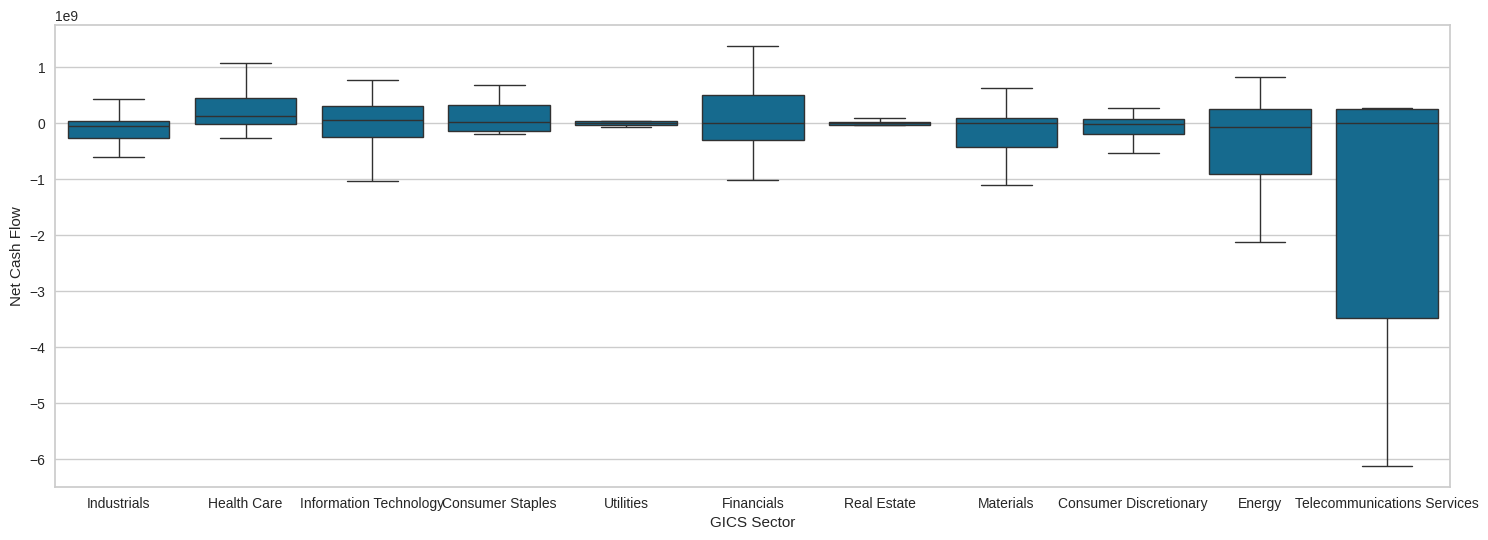

In [ ]:
# ignores outliers for better data visualization
plt.figure(figsize=(18, 6))
sns.boxplot(x='GICS Sector', y='Net Cash Flow', data=df, showfliers=False)
plt.show()

Observations: Most sectors have similar rates of net cash flow, falling between -1 and 1. However, the Telecommunications Services sector ranges from ~0.25 to ~6 while Energy ranges from -2 to 1.

####Economic Sector vs. Net Income

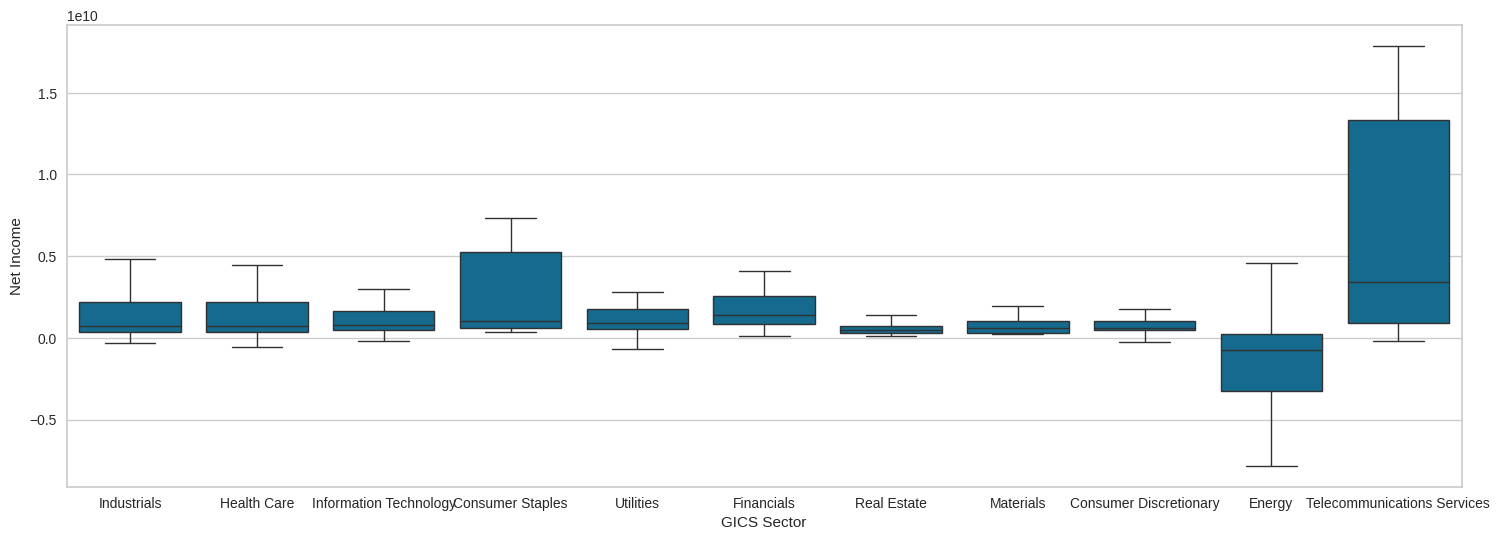

In [ ]:
# removes outliers for better data visualization
plt.figure(figsize=(18, 6))
sns.boxplot(x='GICS Sector', y='Net Income', data=df, showfliers=False)
plt.show()

Observations: Most economic sectors have similar net incomes. However, the Telecommunication Services sector appears to have a higher net income. Meanwhile, the Energy sector appears to have a lower net income.

####Economic Sector vs. Earnings per Share

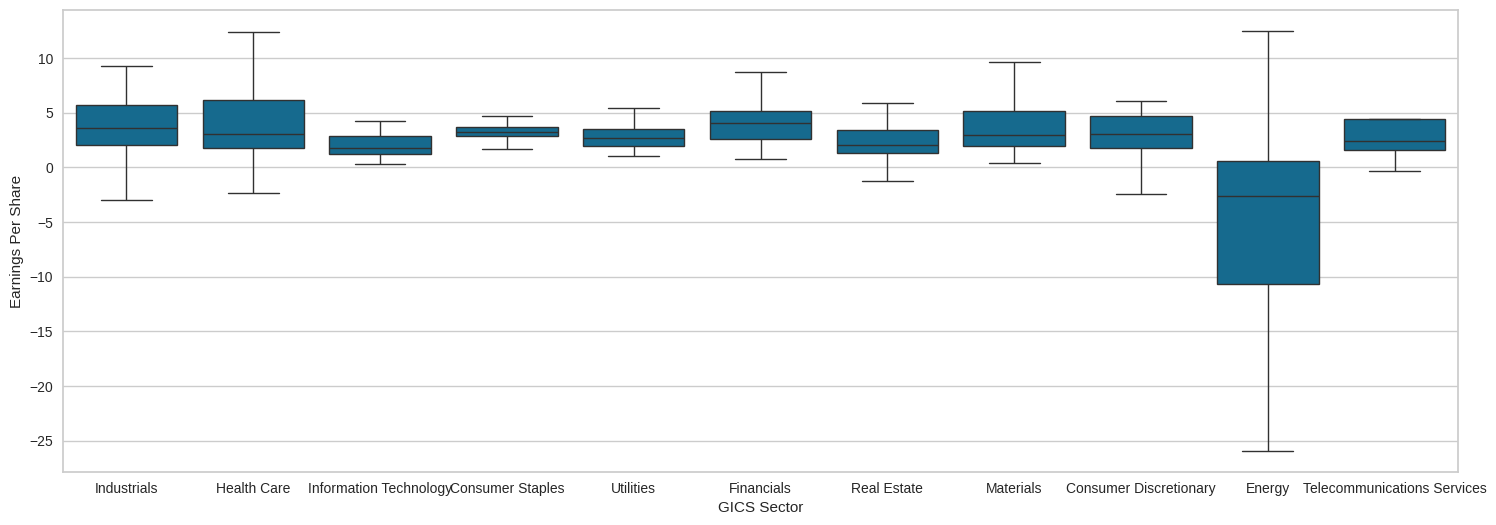

In [ ]:
# ignores outliers for better data visualization
plt.figure(figsize=(18, 6))
sns.boxplot(x='GICS Sector', y='Earnings Per Share', data=df, showfliers=False)
plt.show()

Observations: All economic sectors have around the same earnings per share, with the exception of the Energy sector. The Energy sector earnings per share ranges from ~-26 to ~12.

#### Economic Sector vs. Estimated Shares Outstanding

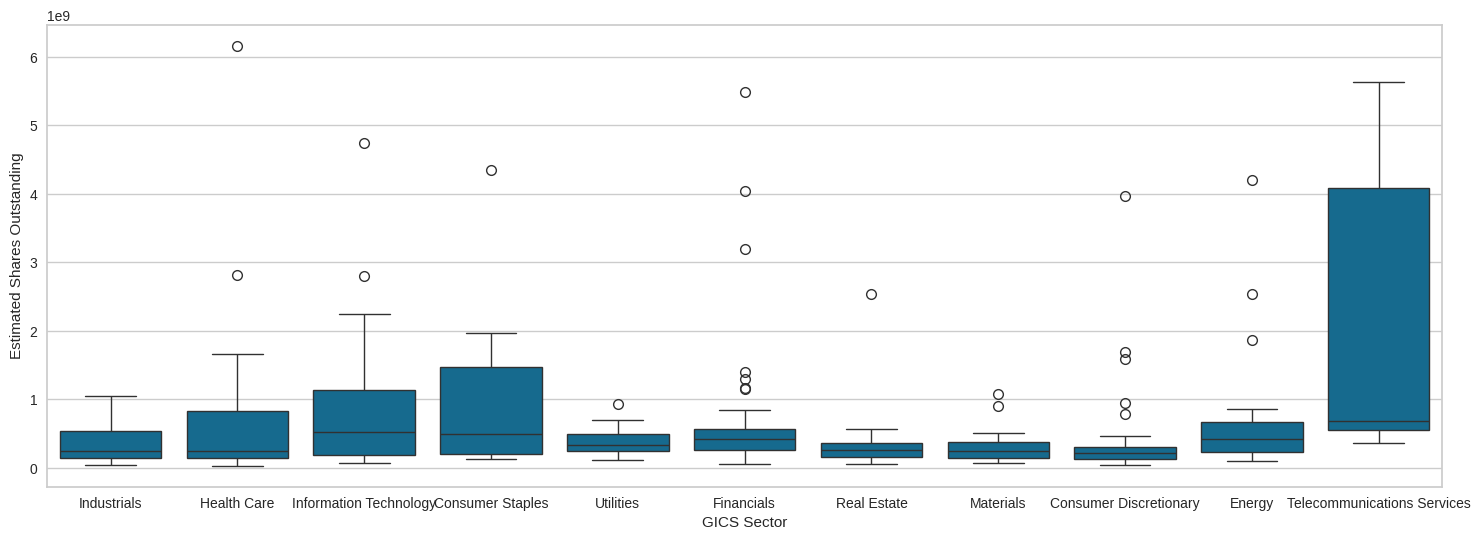

In [ ]:
plt.figure(figsize=(18, 6))
sns.boxplot(x='GICS Sector', y='Estimated Shares Outstanding', data=df)
plt.show()

Observations: The Telecommunication Services sector looks like it has higher estimated outstanding shares.

####Economic Sector vs. P/E Ratio

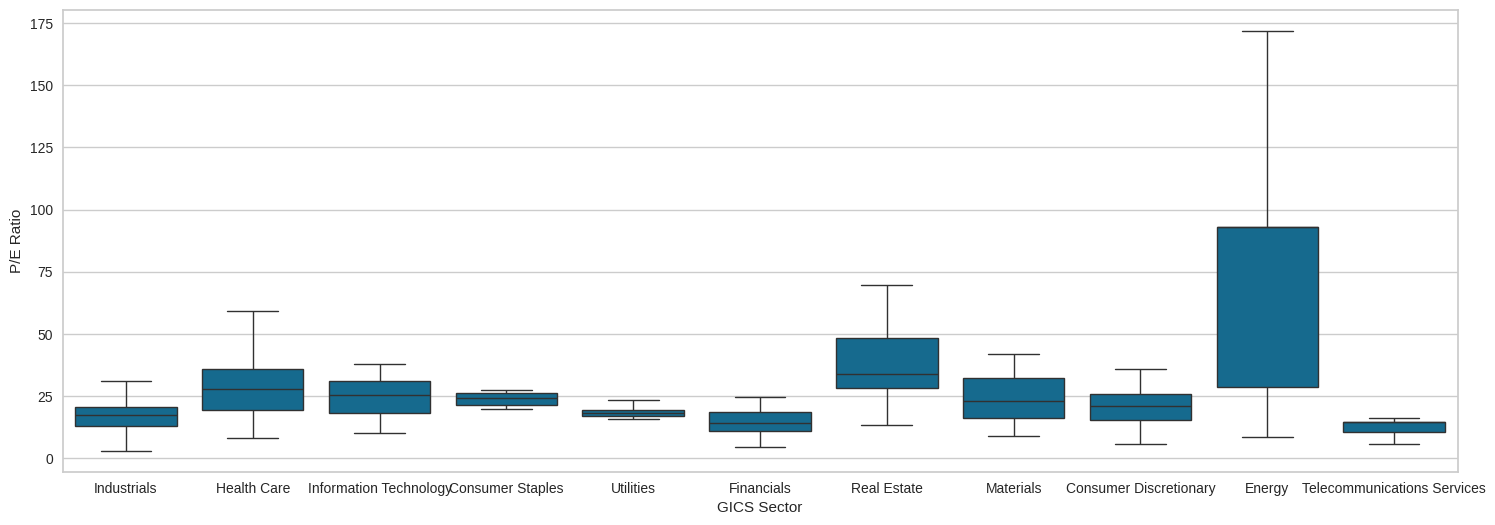

In [ ]:
# ignores outliers for better data visualization
plt.figure(figsize=(18, 6))
sns.boxplot(x='GICS Sector', y='P/E Ratio', data=df, showfliers=False)
plt.show()

Observations: The Energy sector has the highest variability regarding P/E Ratio, ranging from ~12 to ~175.

#### Economic Sector vs. P/B Ratio

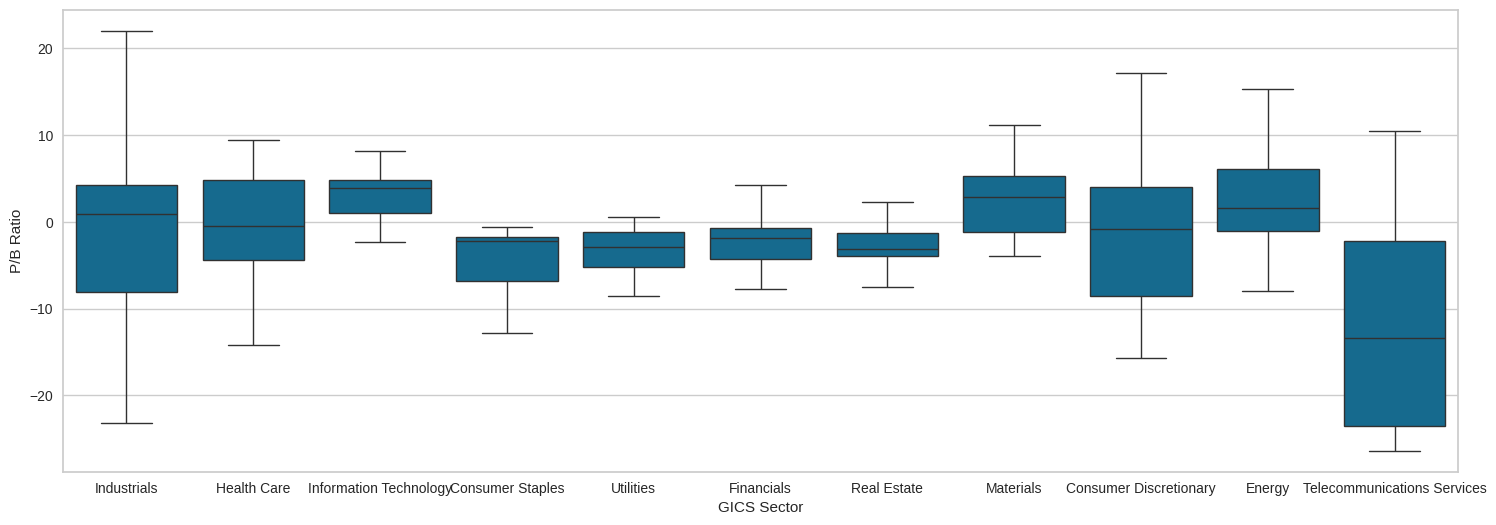

In [ ]:
# removes outliers for better data visualization
plt.figure(figsize=(18, 6))
sns.boxplot(x='GICS Sector', y='P/B Ratio', data=df, showfliers=False)
plt.show()

Observations: The Industrials, Telecommunications Services, Consumer Discretionary, Health Care, and Energy economic sectors have greater ranges regarding P/B Ratios. Industrials has the highest variability.

## Data Preprocessing

- Duplicate value check
- Missing value treatment
- Outlier check
- Feature engineering (if needed)
- Any other preprocessing steps (if needed)

### Missing Value Check

In [ ]:
# returns sum of null value counts
df.isna().sum()

,0
Ticker Symbol,0
Security,0
GICS Sector,0
GICS Sub Industry,0
Current Price,0
Price Change,0
Volatility,0
ROE,0
Cash Ratio,0
Net Cash Flow,0


No missing or null values.

### Duplicate Value Check

In [ ]:
# returns sum duplicate values counts
df.duplicated().sum()

np.int64(0)

No duplicate values.

### Outlier Check

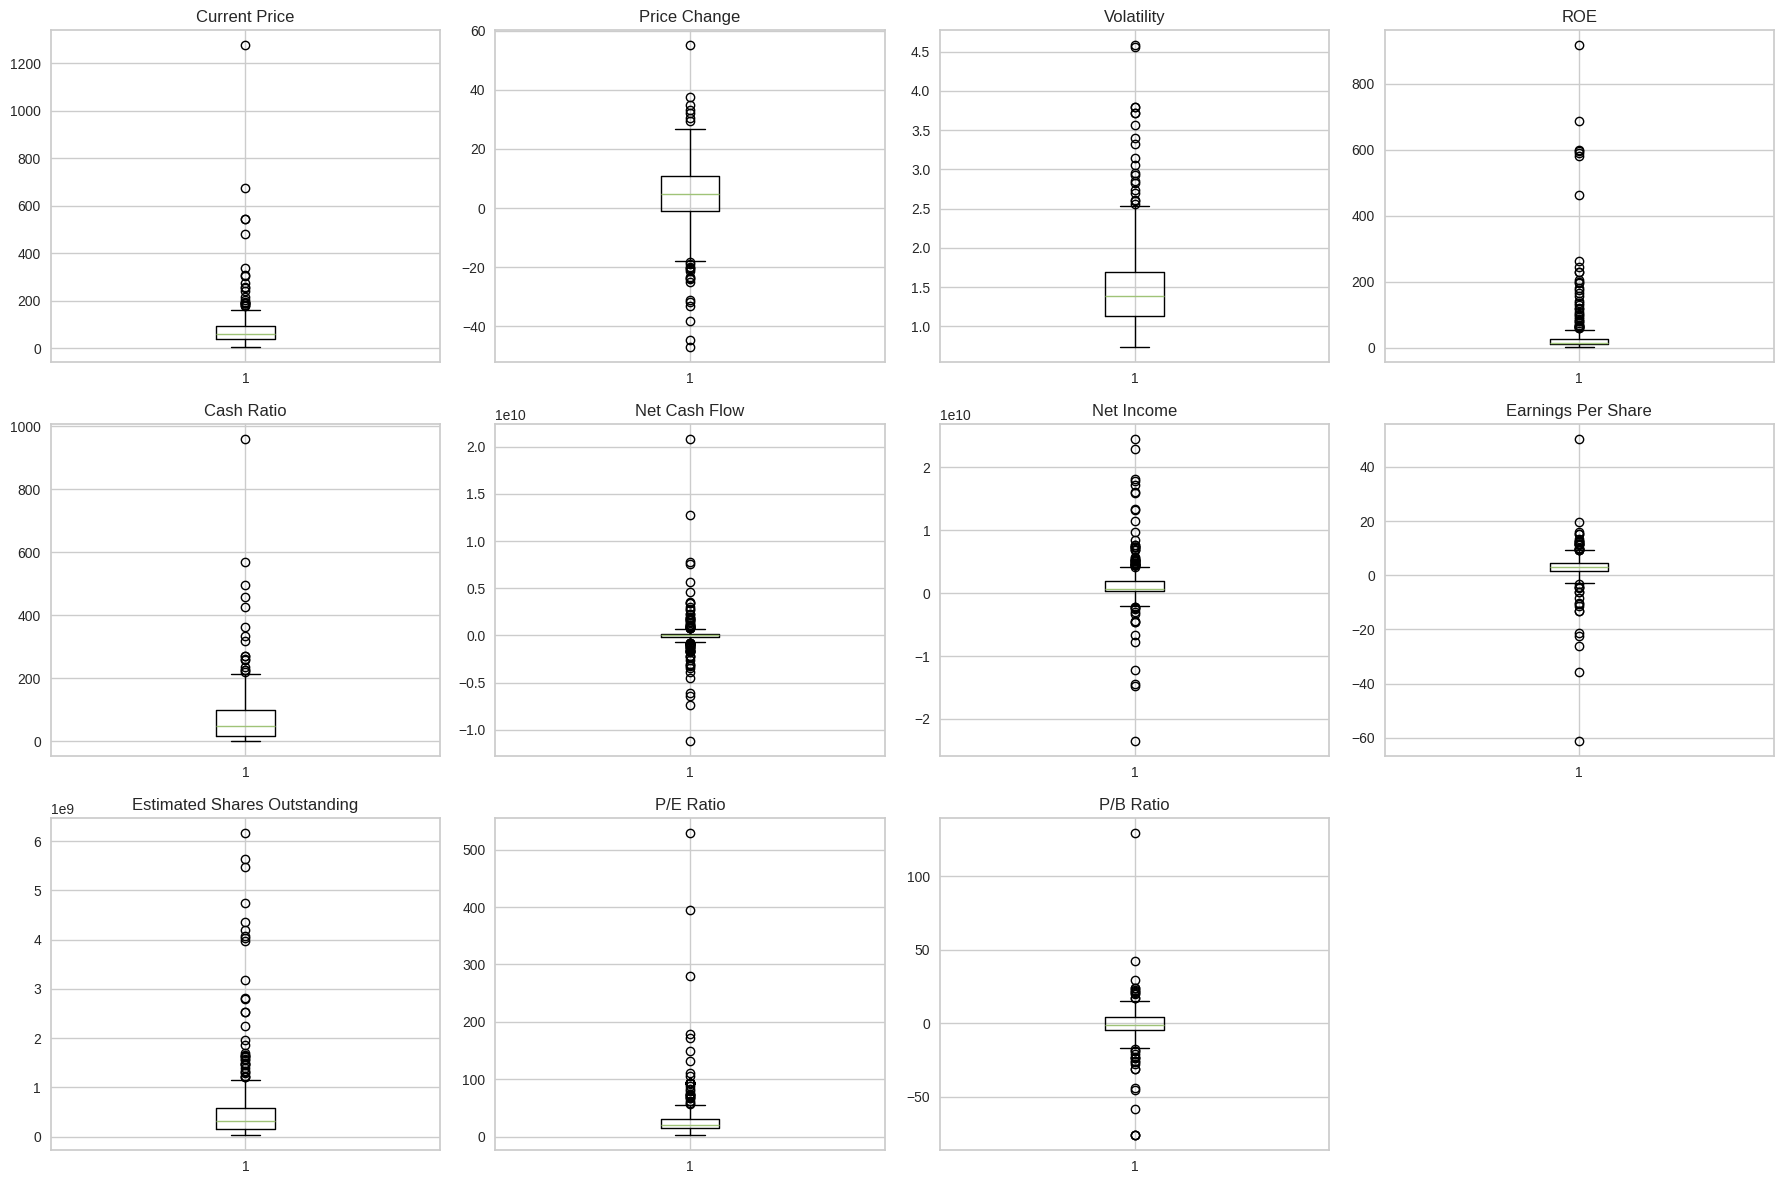

In [ ]:
plt.figure(figsize=(18, 12))
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

for i, variable in enumerate(numeric_columns):
    plt.subplot(3, 4, i + 1)
    plt.boxplot(df[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

### Scaling

In [ ]:
# scales data before clustering
scaler = StandardScaler()
subset = df[numeric_columns].copy()
subset_scaled = scaler.fit_transform(subset)

In [ ]:
df_subset_scaled = pd.DataFrame(subset_scaled, columns = subset.columns)

## EDA

- It is a good idea to explore the data once again after manipulating it.

In [ ]:
df_subset_scaled.head()

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
0,-0.393341,0.493950,0.272749,0.989601,-0.210698,-0.339355,1.554415,1.309399,0.107863,-0.652487,-0.506653
1,-0.220837,0.355439,1.137045,0.937737,0.077269,-0.002335,0.927628,0.056755,1.250274,-0.311769,-0.504205
2,-0.367195,0.602479,-0.427007,-0.192905,-0.033488,0.454058,0.744371,0.024831,1.098021,-0.391502,0.094941
3,0.133567,0.825696,-0.284802,-0.317379,1.218059,-0.152497,-0.219816,-0.230563,-0.091622,0.947148,0.424333
4,-0.260874,-0.492636,0.296470,-0.265515,2.237018,0.133564,-0.202703,-0.374982,1.978399,3.293307,0.199196


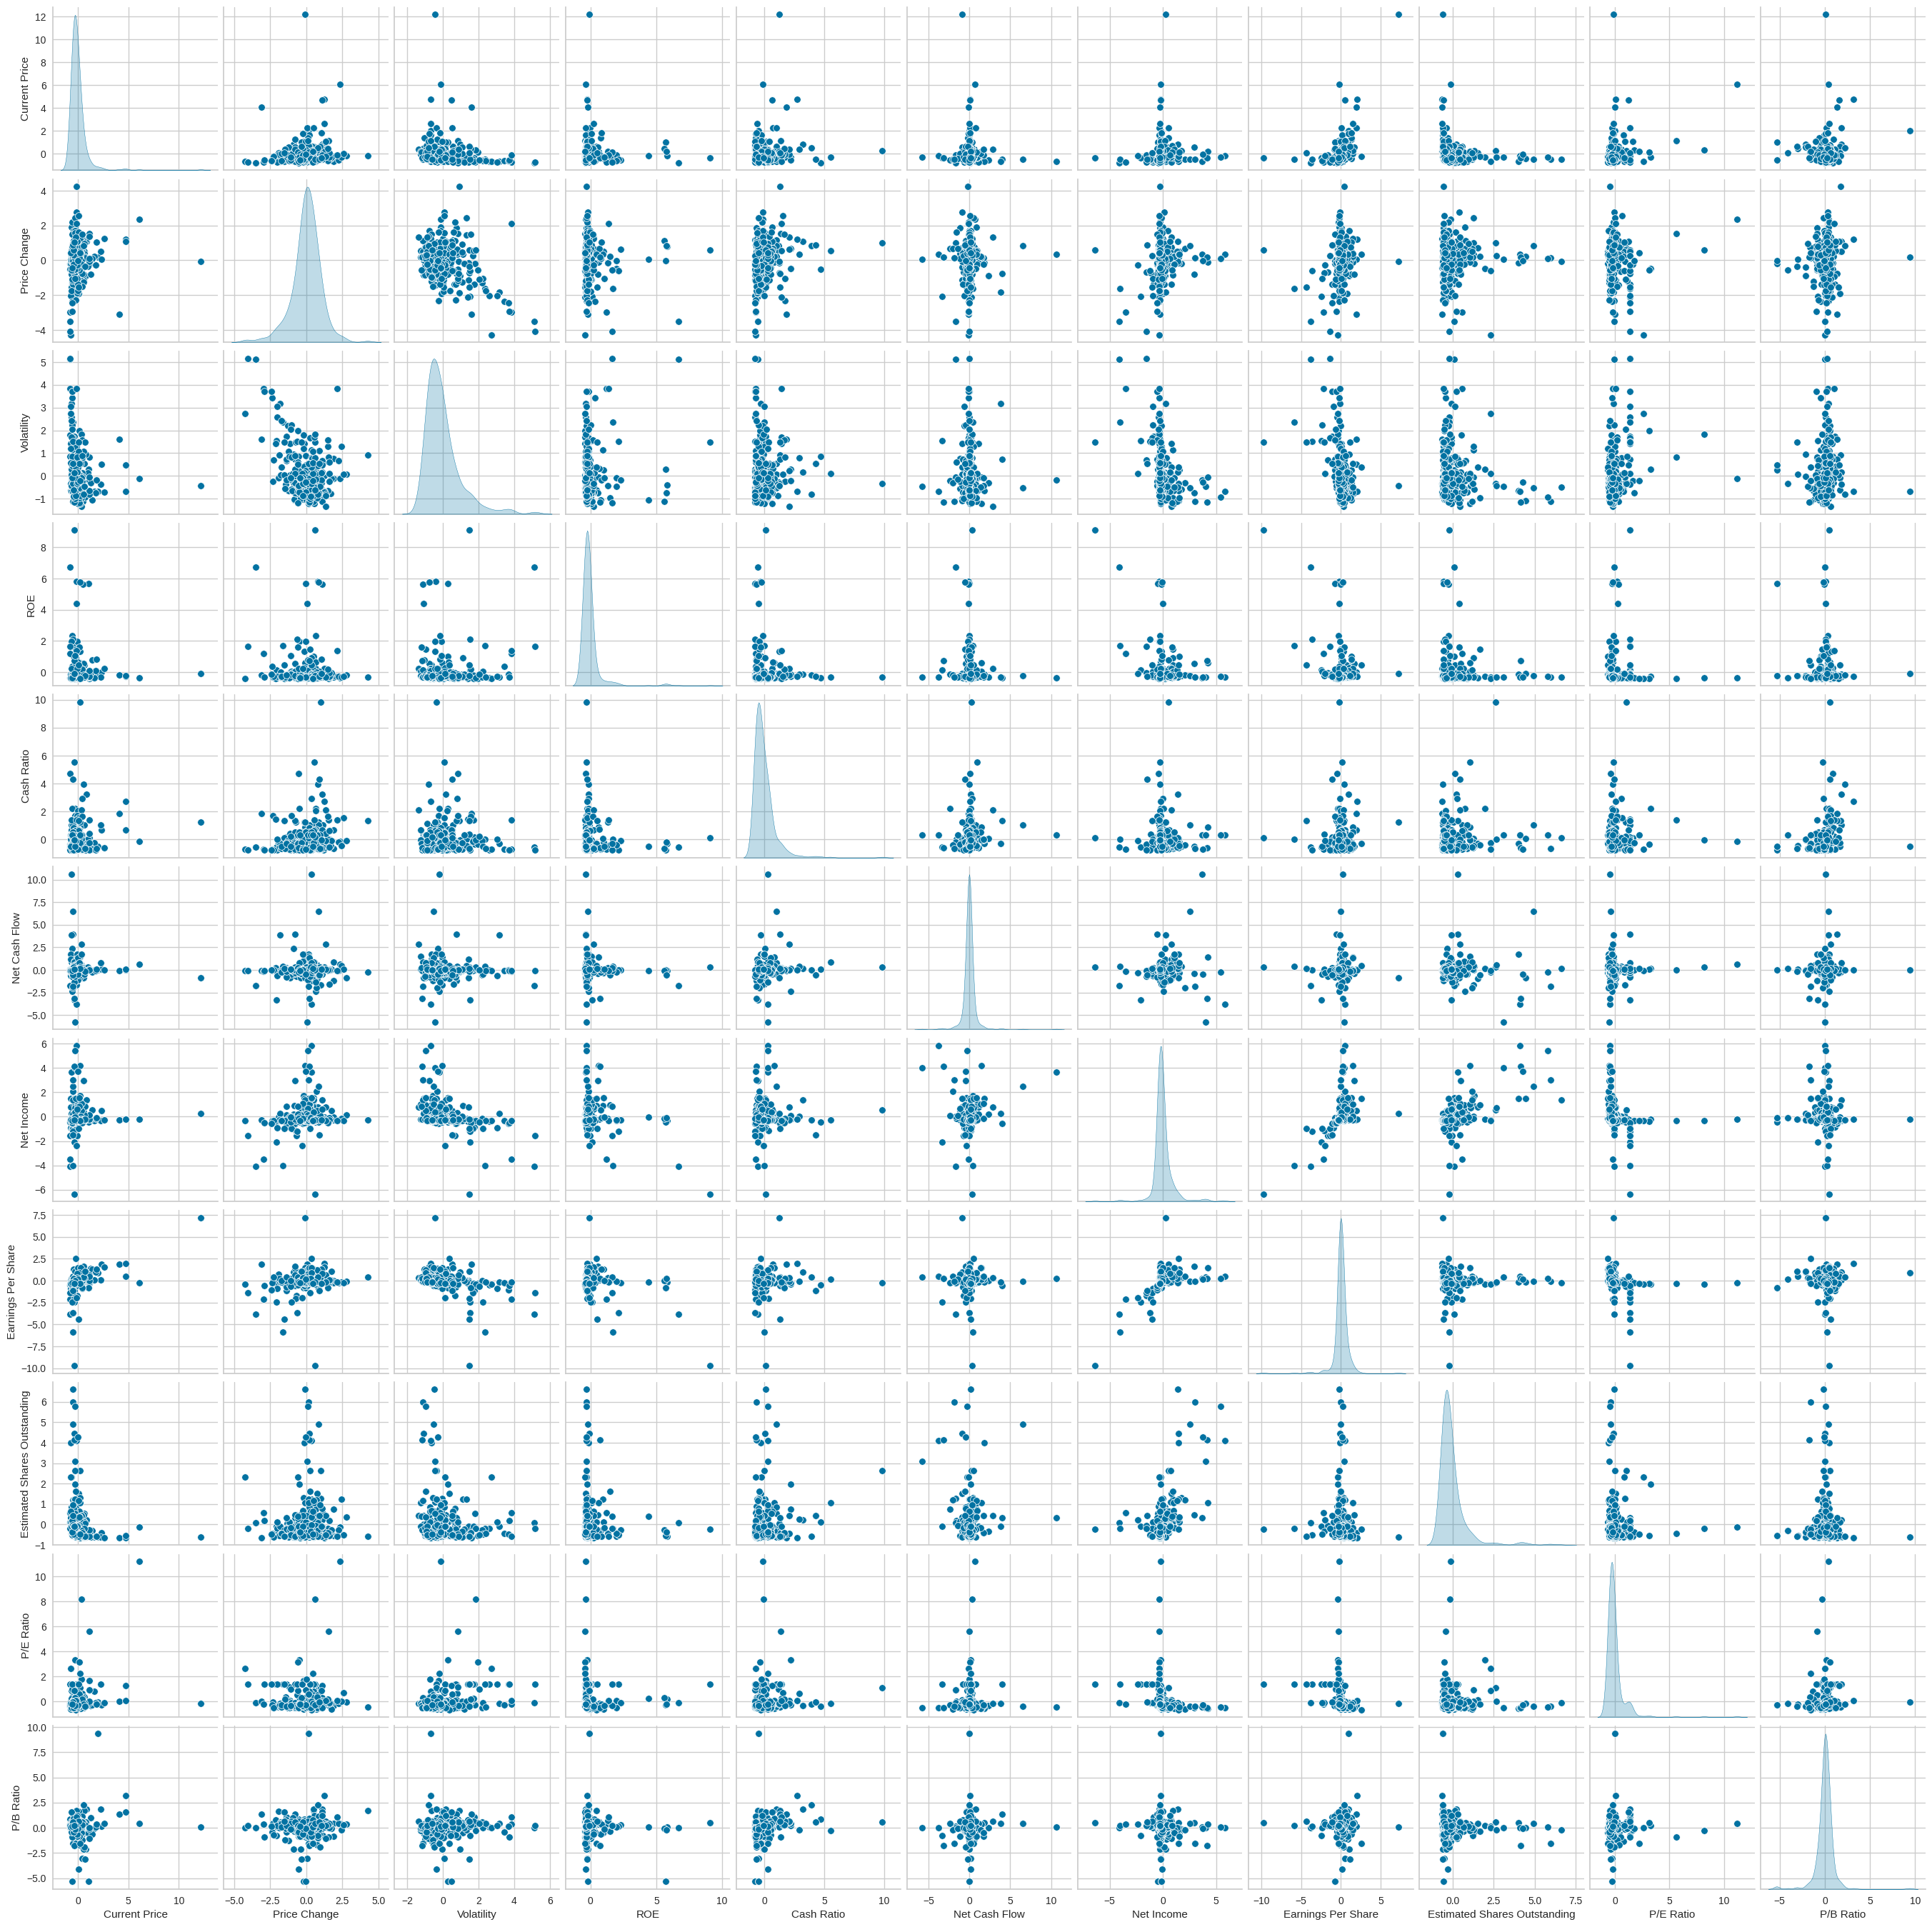

In [ ]:
sns.pairplot(df_subset_scaled, diag_kind="kde")

## K-means Clustering

### Elbow Plot

In [ ]:
df_k_means = df_subset_scaled.copy()

Number of Clusters: 1 	Average Distortion: 2.5425069919221697
Number of Clusters: 2 	Average Distortion: 2.3862098789299604
Number of Clusters: 3 	Average Distortion: 2.33620927590848
Number of Clusters: 4 	Average Distortion: 2.219050563833442
Number of Clusters: 5 	Average Distortion: 2.133404401901685
Number of Clusters: 6 	Average Distortion: 2.081503686093715
Number of Clusters: 7 	Average Distortion: 2.0045413402786814
Number of Clusters: 8 	Average Distortion: 1.9864237824874411
Number of Clusters: 9 	Average Distortion: 1.956222103389025


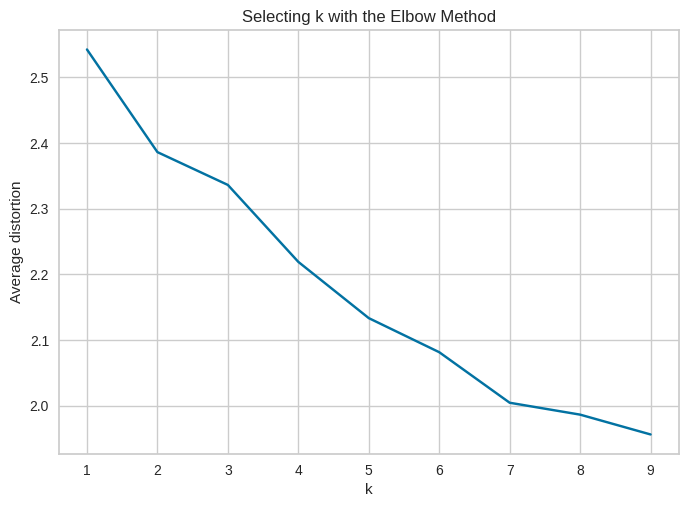

In [ ]:
clusters = range(1, 10)
meanDistortions = []

for k in clusters:
    model = KMeans(n_clusters=k, random_state=1)
    model.fit(df_k_means)
    prediction = model.predict(df_k_means)
    distortion = (
        sum(
            np.min(cdist(df_k_means, model.cluster_centers_, "euclidean"), axis=1)
        )
        / df_k_means.shape[0]
    )

    meanDistortions.append(distortion)

    print("Number of Clusters:", k, "\tAverage Distortion:", distortion)

plt.plot(clusters, meanDistortions, "bx-")
plt.xlabel("k")
plt.ylabel("Average distortion")
plt.title("Selecting k with the Elbow Method")
plt.show()

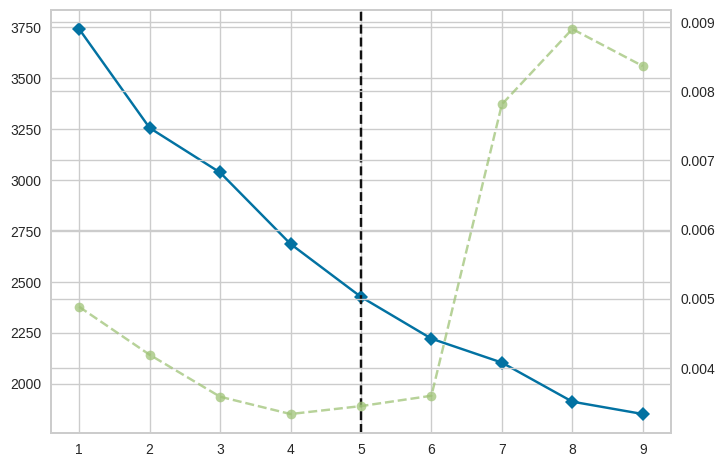

In [ ]:
model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(1,10), timings=True)
visualizer.fit(df_k_means)
visualizer = model.predict(df_k_means)

Observations: The K-value at the elbow appears to be 4 or 5.



### Silhouette Scores

For n_clusters = 2, the silhouette score is 0.45335782729503565)
For n_clusters = 3, the silhouette score is 0.40374060030338865)
For n_clusters = 4, the silhouette score is 0.4246430808437099)
For n_clusters = 5, the silhouette score is 0.4381539778147092)
For n_clusters = 6, the silhouette score is 0.40869599703024256)
For n_clusters = 7, the silhouette score is 0.1207450219233897)
For n_clusters = 8, the silhouette score is 0.3693991650696542)
For n_clusters = 9, the silhouette score is 0.35185096182499204)


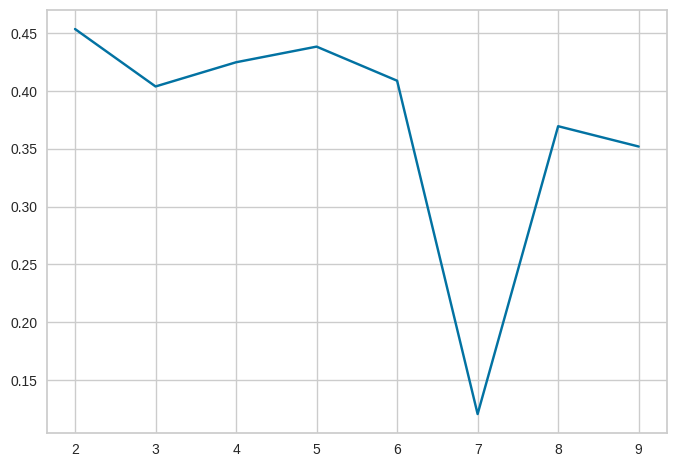

In [ ]:
# provides silhoutte scores
sil_score = []
cluster_list = list(range(2, 10))
for n_clusters in cluster_list:
    clusterer = KMeans(n_clusters=n_clusters, random_state=1)
    preds = clusterer.fit_predict((df_k_means))
    # centers = clusterer.cluster_centers_
    score = silhouette_score(df_k_means, preds)
    sil_score.append(score)
    print("For n_clusters = {}, the silhouette score is {})".format(n_clusters, score))

plt.plot(cluster_list, sil_score)
plt.show()

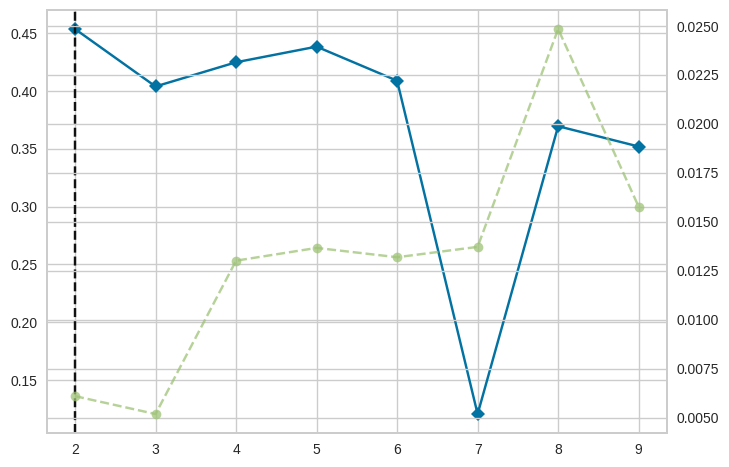

In [ ]:
model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(2,10), metric="silhouette", timings=True)
visualizer.fit(df_k_means)
visualizer = model.predict(df_k_means)

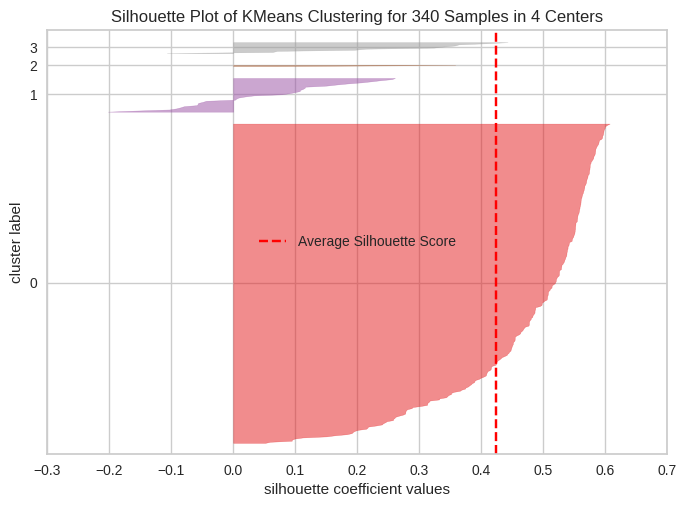

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 340 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
# displays silhouette plot with 4 clusters
visualizer = SilhouetteVisualizer(KMeans(4, random_state=1))
visualizer.fit(df_k_means)
visualizer.show()

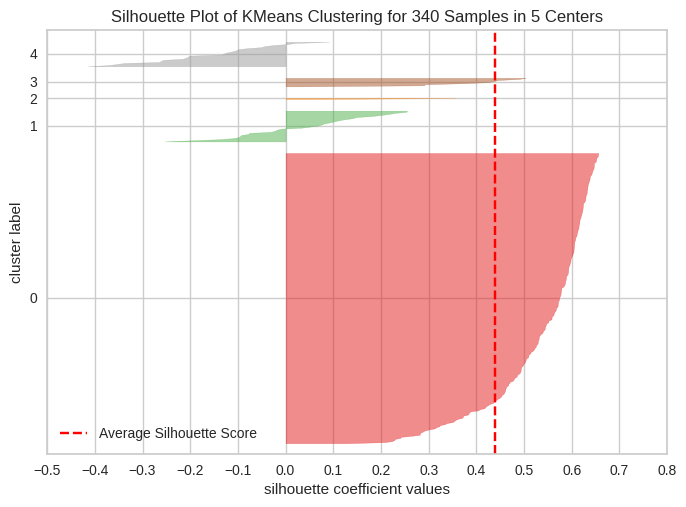

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 340 Samples in 5 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
# displays silhouette plot with 5 clusters
visualizer = SilhouetteVisualizer(KMeans(5, random_state=1))
visualizer.fit(df_k_means)
visualizer.show()

Observations: Between K=4 and K=5, k=4 has the highest silhouette score. Therefore, the optimal number of clusters is 4.

### Final Model

In [ ]:
# final K-means model
kmeans = KMeans(n_clusters=4, random_state=1)
kmeans.fit(df_k_means)

KMeans(n_clusters=4, random_state=1)

In [ ]:
df1 = df.copy()

# appends K-means cluster labels to original and K-means dataframes
df1["K-means Segments"] = kmeans.labels_
df_k_means["K-means Segments"] = kmeans.labels_

### Cluster Profiling

In [ ]:
# profiles clusters based on mean values
cluster_profile = df1[df1.select_dtypes(include=np.number).columns].groupby("K-means Segments").mean()

In [ ]:
cluster_profile["Segment Count"] = df1.groupby("K-means Segments")["Security"].count().values

In [ ]:
cluster_profile.style.highlight_max(color="green", axis=0)

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio,Segment Count
K-means Segments,,,,,,,,,,,,
0,84.176635,5.702764,1.396635,33.962712,69.972881,90456322.033898,1517730698.305085,3.890390,444140390.526542,24.645180,-2.015145,295
1,64.263438,-10.382780,2.732033,46.812500,69.656250,205568000.000000,-2018462218.750000,-5.177187,526311835.891875,110.425211,1.787692,32
2,24.485001,-13.351992,3.482611,802.000000,51.000000,-1292500000.000000,-19106500000.000000,-41.815000,519573983.250000,60.748608,1.565141,2
3,50.517273,5.747586,1.130399,31.090909,75.909091,-1072272727.272727,14833090909.090910,4.154545,4298826628.727273,14.803577,-4.552119,11


In [ ]:
for cl in df1["K-means Segments"].unique():
    print("In cluster {}, the following companies are present:".format(cl))
    print(df1[df1["K-means Segments"] == cl]["Security"].unique())
    print()

In cluster 0, the following companies are present:
['American Airlines Group' 'AbbVie' 'Abbott Laboratories'
 'Adobe Systems Inc' 'Archer-Daniels-Midland Co' 'Alliance Data Systems'
 'Ameren Corp' 'American Electric Power' 'AFLAC Inc'
 'American International Group, Inc.' 'Apartment Investment & Mgmt'
 'Assurant Inc' 'Arthur J. Gallagher & Co.' 'Akamai Technologies Inc'
 'Albemarle Corp' 'Alaska Air Group Inc' 'Allstate Corp' 'Allegion'
 'Applied Materials Inc' 'AMETEK Inc' 'Affiliated Managers Group Inc'
 'Amgen Inc' 'Ameriprise Financial' 'American Tower Corp A'
 'AutoNation Inc' 'Anthem Inc.' 'Aon plc' 'Amphenol Corp' 'Arconic Inc'
 'Activision Blizzard' 'AvalonBay Communities, Inc.' 'Broadcom'
 'American Water Works Company Inc' 'American Express Co' 'Boeing Company'
 'Bank of America Corp' 'Baxter International Inc.' 'BB&T Corporation'
 'Bard (C.R.) Inc.' 'BIOGEN IDEC Inc.' 'The Bank of New York Mellon Corp.'
 'Ball Corp' 'Bristol-Myers Squibb' 'Boston Scientific' 'BorgWarner'
 'B

In [ ]:
df1.groupby(["K-means Segments", "GICS Sector"])["Security"].count()

K-means Segments  GICS Sector                
0                 Consumer Discretionary         37
                  Consumer Staples               18
                  Energy                          5
                  Financials                     46
                  Health Care                    37
                  Industrials                    52
                  Information Technology         28
                  Materials                      18
                  Real Estate                    27
                  Telecommunications Services     3
                  Utilities                      24
1                 Consumer Discretionary          2
                  Energy                         22
                  Health Care                     1
                  Industrials                     1
                  Information Technology          4
                  Materials                       2
2                 Energy                          2
3                 Consumer Discretionary          1
                  Consumer Staples                1
                  Energy                          1
                  Financials                      3
                  Health Care                     2
                  Information Technology          1
                  Telecommunications Services     2
Name: Security, dtype: int64

Observations: Here we can observe the number of companies in each cluster from each economic sector.

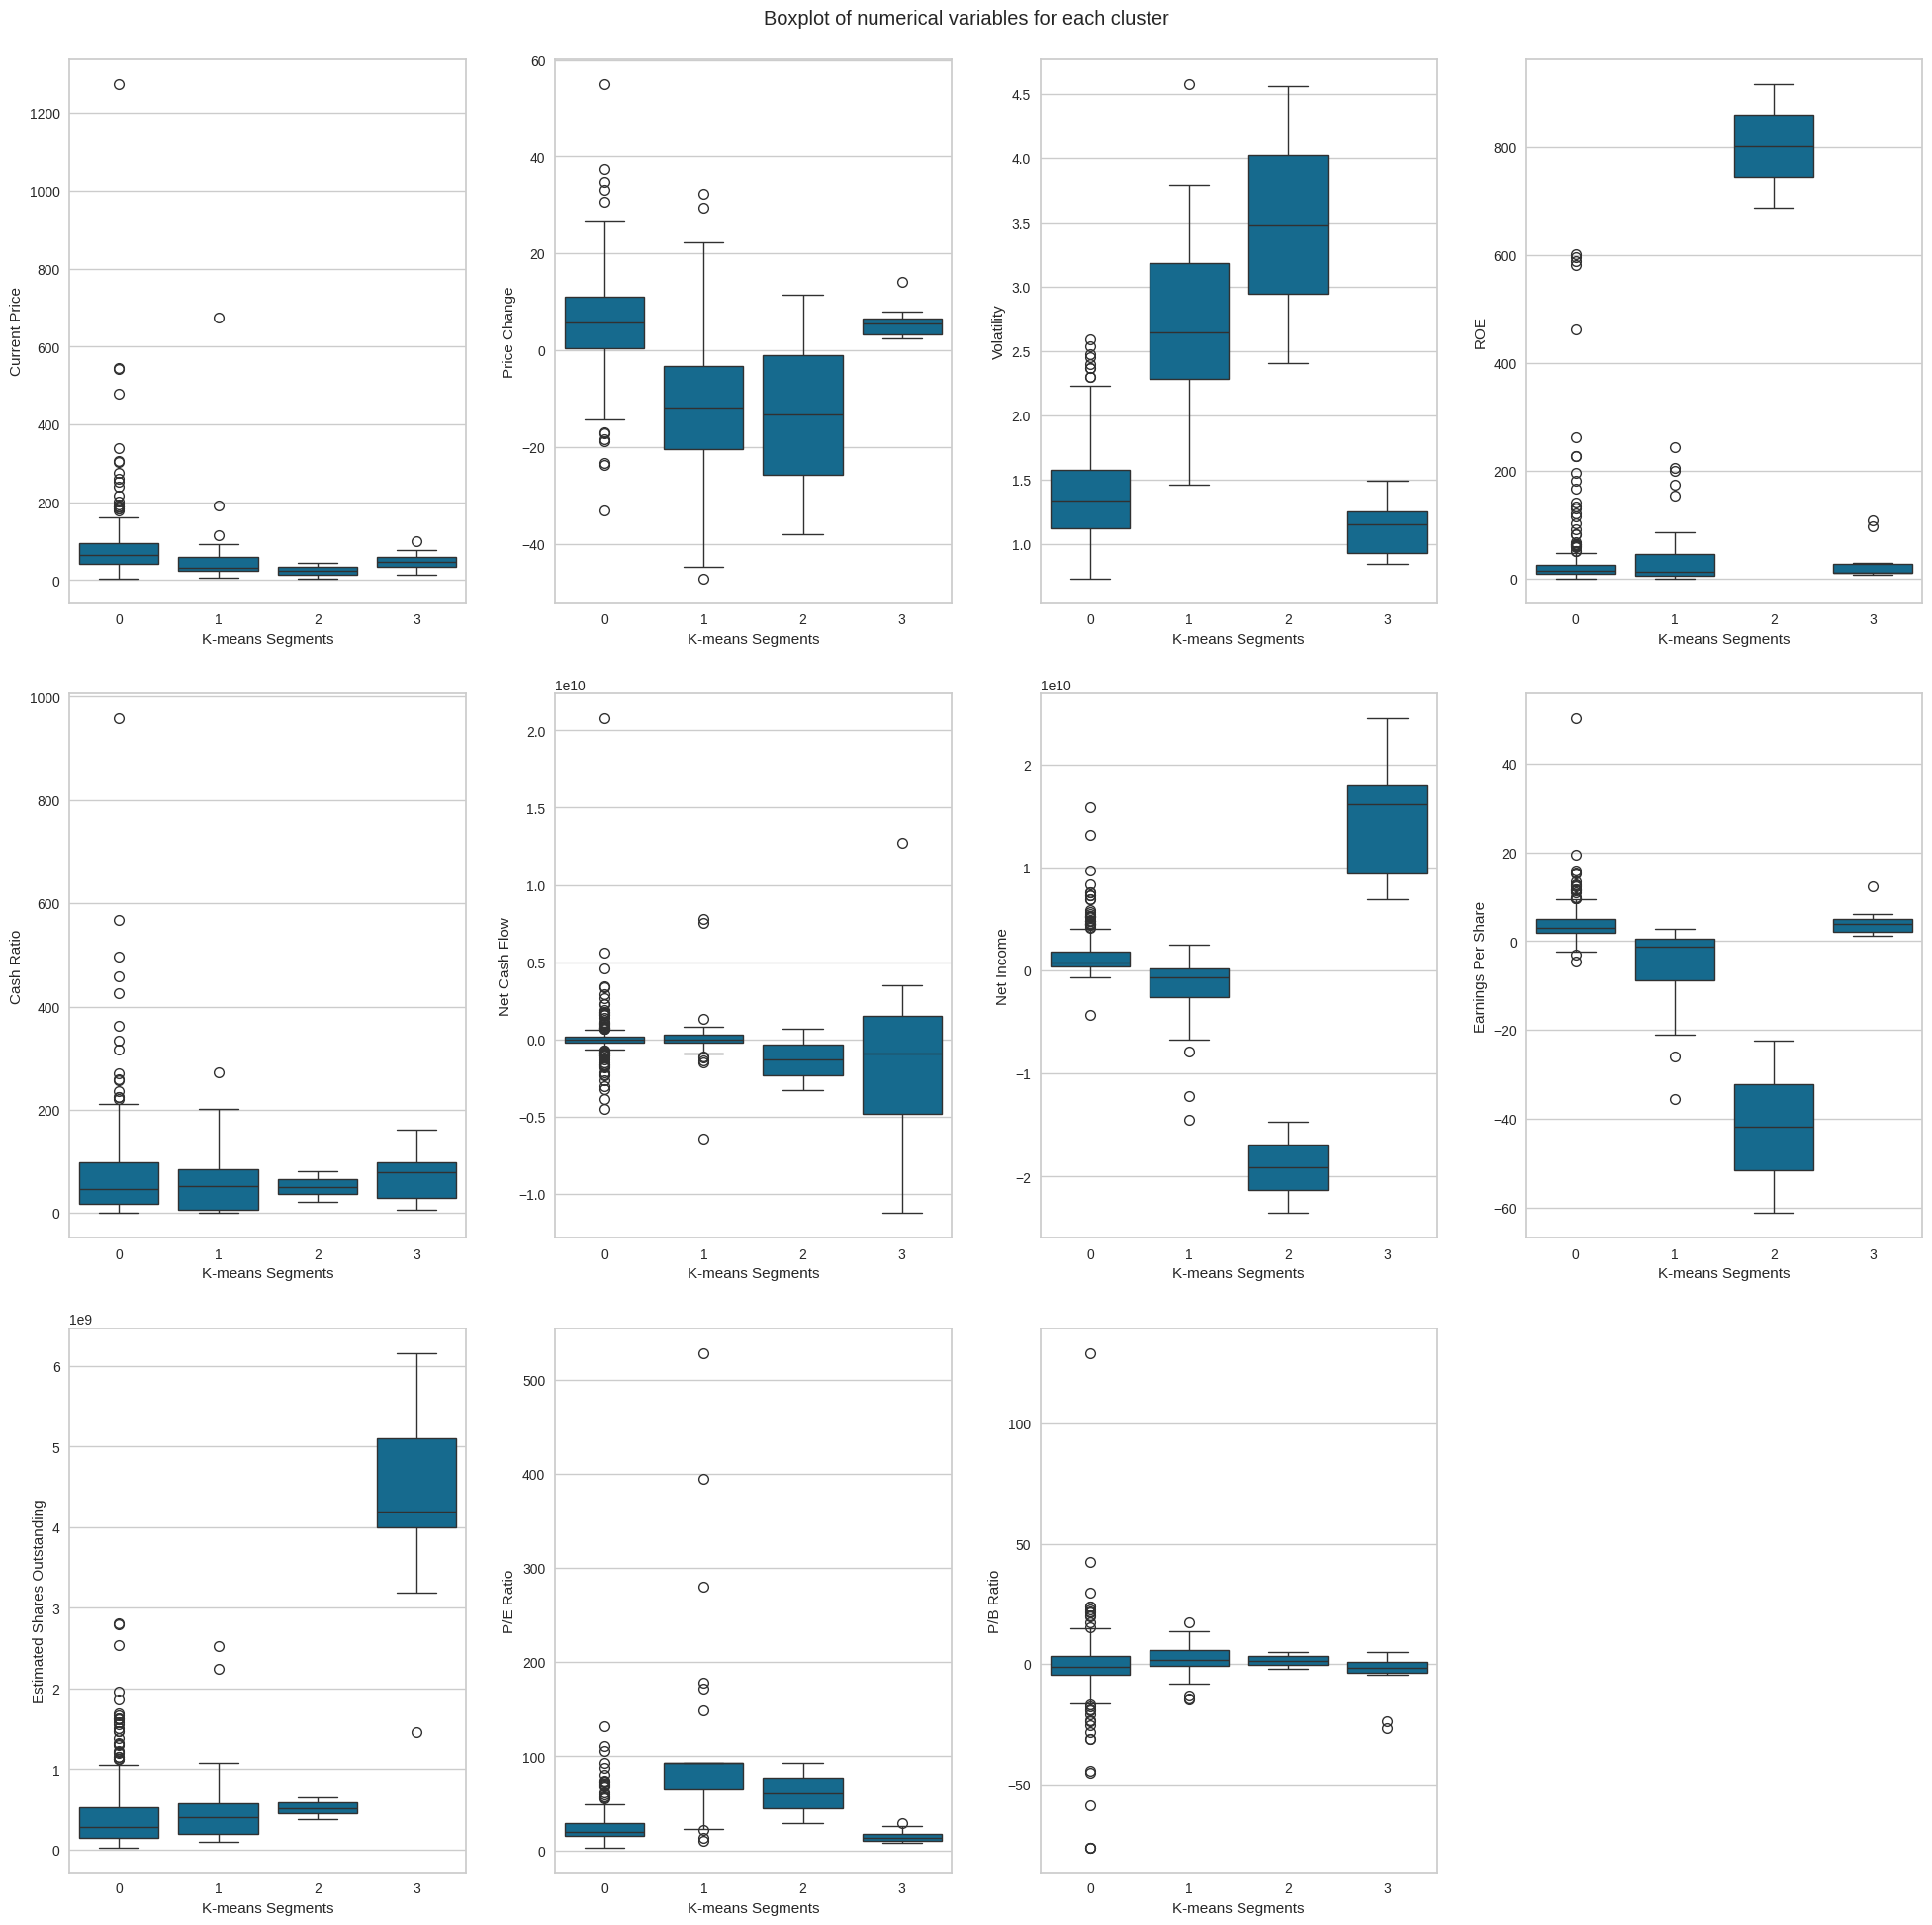

In [ ]:
# original dataframe
plt.figure(figsize=(20, 20))
plt.suptitle("Boxplot of numerical variables for each cluster")

for i, variable in enumerate(numeric_columns):
    plt.subplot(3, 4, i + 1)
    sns.boxplot(data=df1, x="K-means Segments", y=variable)

plt.tight_layout(pad=2.0)

### Insights



-   Cluster 0:
  - The average current price of this cluster (\$72.4) is closest to the average current price of all stocks (~\$80).
  - The stocks in this cluster exhibit moderate price change, volatility, and cash ratios.
  - This cluster has the highest segment count, meaning most stocks display these patterns.
  - Based on these characteristics, the stocks in this cluster are low-risk, and the cluster represents the market norm.

-   Cluster 1:
  - The average current price of this cluster (\$50.5) is lower than the average current price of all stocks.
  - The stocks in this cluster have the lowest volatility, meaning that these stocks are the most stable in the dataset.
  - The average net income and estimated shares outstanding are very high, indicating that these stocks are strong outliers compared to the market norm.
  - This cluster has the least amount of stocks (11).
  - The stocks in this cluster are also low-risk, and the cluster represents undervalued, high-earning stocks.

-   Cluster 2:
  - This cluster has the lowest average price (~\$38).
  - The stocks in this cluster are actually losing value, with the highest negative price change.
  - This cluster is the most volatile, meaning the stocks are not stable.
  - These firms are incurring losses. They have the lowest net income and earnings per share.
  - The stocks in this cluster are high-risk and high-loss. This cluster represents unprofitable stocks.

-  Cluster 3:
  - This cluster contains high value stocks, with a median current price of ~\$225 and a mean current price of \$234.
  - These stocks experience the greatest positive price change, averaging a 13.4 percent change.
  - These stocks also have the highest cash ratio and net cash flow, indicating that they are financially strong and very profitable.
  - The high P/E Ratio suggests that the stocks in this cluster are expensive relative to their earnings.
  - The volatility is higher than Clusters 0 and 1, meaning these stocks are not as stable.
  - Based on these characteristics, this cluster is composed of high growth, moderate risk stocks.  


## Hierarchical Clustering

### Cophenetic Correlation

In [ ]:
df_hc = df_subset_scaled.copy()

In [ ]:
distance_metrics = ["euclidean", "chebyshev", "mahalanobis", "cityblock"]
linkage_methods = ["single", "complete", "average", "weighted"]

high_cophenet_corr = 0
high_dm_lm = [0, 0]

for dm in distance_metrics:
    for lm in linkage_methods:
        Z = linkage(df_hc, metric=dm, method=lm)
        c, coph_dists = cophenet(Z, pdist(df_hc))
        print(
            "Cophenetic correlation for {} distance and {} linkage is {}.".format(
                dm.capitalize(), lm, c
            )
        )
        if high_cophenet_corr < c:
            high_cophenet_corr = c
            high_dm_lm[0] = dm
            high_dm_lm[1] = lm

Cophenetic correlation for Euclidean distance and single linkage is 0.9232271494002922.
Cophenetic correlation for Euclidean distance and complete linkage is 0.7873280186580672.
Cophenetic correlation for Euclidean distance and average linkage is 0.9422540609560814.
Cophenetic correlation for Euclidean distance and weighted linkage is 0.8693784298129404.
Cophenetic correlation for Chebyshev distance and single linkage is 0.9062538164750717.
Cophenetic correlation for Chebyshev distance and complete linkage is 0.598891419111242.
Cophenetic correlation for Chebyshev distance and average linkage is 0.9338265528030499.
Cophenetic correlation for Chebyshev distance and weighted linkage is 0.9127355892367.
Cophenetic correlation for Mahalanobis distance and single linkage is 0.925919553052459.
Cophenetic correlation for Mahalanobis distance and complete linkage is 0.7925307202850002.
Cophenetic correlation for Mahalanobis distance and average linkage is 0.9247324030159736.
Cophenetic correla

In [ ]:
# prints distance metric and linkage method with the highest cophenetic correlation
print('*'*100)
print(
    "Highest cophenetic correlation is {}, which is obtained with {} distance and {} linkage.".format(
        high_cophenet_corr, high_dm_lm[0].capitalize(), high_dm_lm[1]
    )
)

****************************************************************************************************
Highest cophenetic correlation is 0.9422540609560814, which is obtained with Euclidean distance and average linkage.


In [ ]:
linkage_methods = ["single", "complete", "average", "centroid", "ward", "weighted"]

high_cophenet_corr = 0
high_dm_lm = [0, 0]

for lm in linkage_methods:
    Z = linkage(df_subset_scaled, metric="euclidean", method=lm)
    c, coph_dists = cophenet(Z, pdist(df_subset_scaled))
    print("Cophenetic correlation for {} linkage is {}.".format(lm, c))
    if high_cophenet_corr < c:
        high_cophenet_corr = c
        high_dm_lm[0] = "euclidean"
        high_dm_lm[1] = lm

Cophenetic correlation for single linkage is 0.9232271494002922.
Cophenetic correlation for complete linkage is 0.7873280186580672.
Cophenetic correlation for average linkage is 0.9422540609560814.
Cophenetic correlation for centroid linkage is 0.9314012446828154.
Cophenetic correlation for ward linkage is 0.7101180299865353.
Cophenetic correlation for weighted linkage is 0.8693784298129404.


In [ ]:
# prints the distance metric and linkage method with the highest cophenetic correlation
print("*" * 100)
print(
    "Highest cophenetic correlation is {}, which is obtained with {} linkage.".format(
        high_cophenet_corr, high_dm_lm[1]
    )
)

****************************************************************************************************
Highest cophenetic correlation is 0.9422540609560814, which is obtained with average linkage.


### Dendrograms

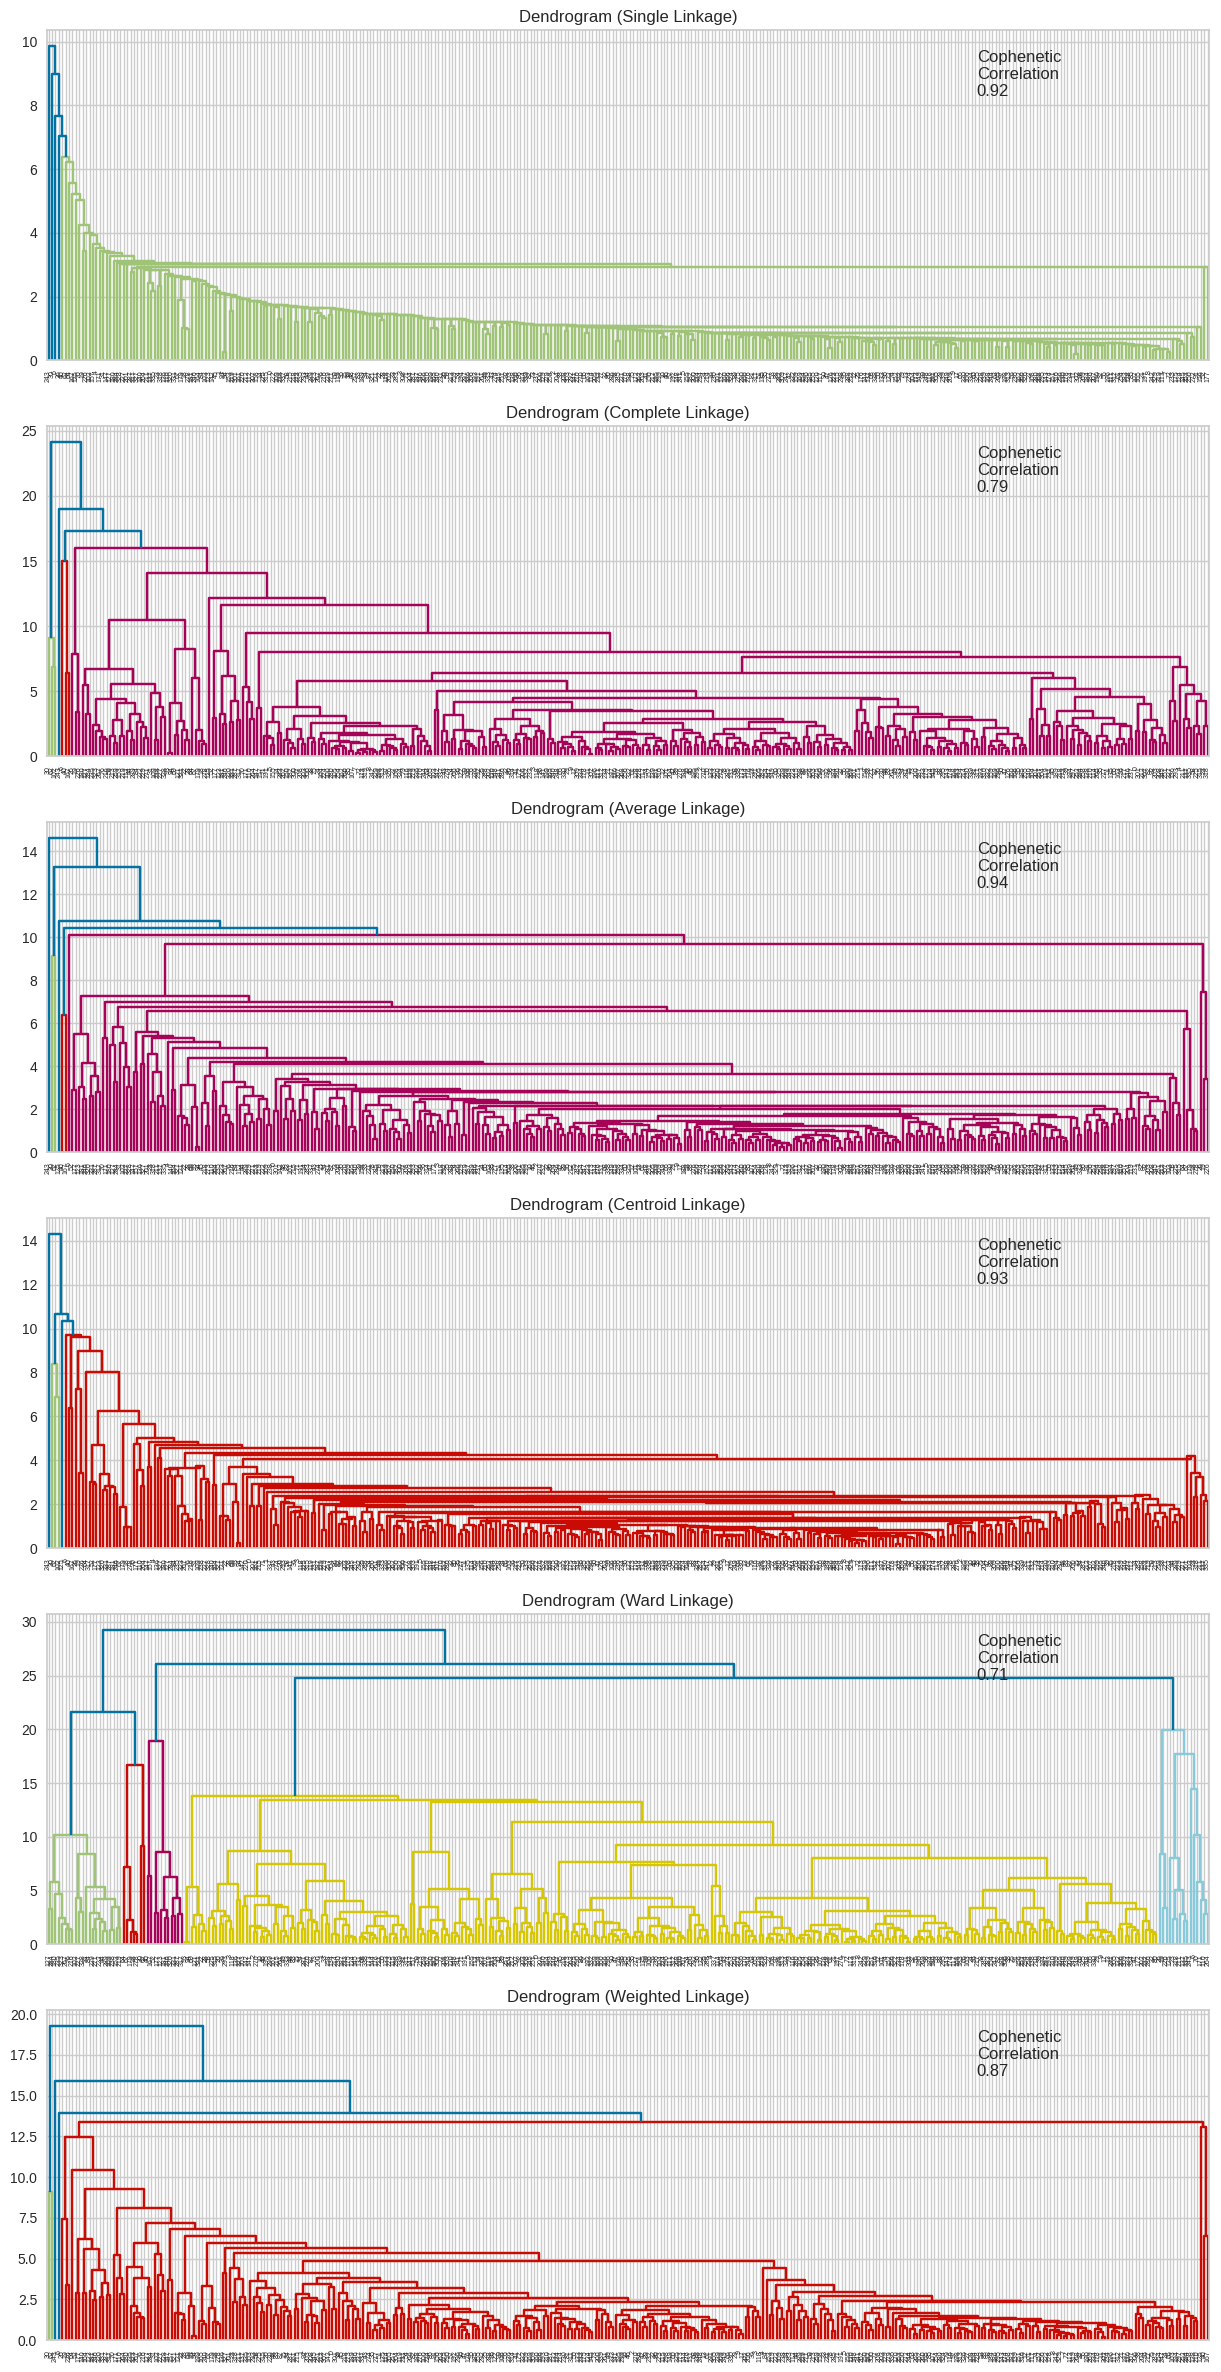

In [ ]:
linkage_methods = ["single", "complete", "average", "centroid", "ward", "weighted"]

compare_cols = ["Linkage", "Cophenetic Coefficient"]
compare = []

fig, axs = plt.subplots(len(linkage_methods), 1, figsize=(15, 30))

# plots dendrogram and calaculates cophenetic correlation for each linkage method
for i, method in enumerate(linkage_methods):
    Z = linkage(df_subset_scaled, metric="euclidean", method=method)

    dendrogram(Z, ax=axs[i])
    axs[i].set_title(f"Dendrogram ({method.capitalize()} Linkage)")

    coph_corr, coph_dist = cophenet(Z, pdist(df_subset_scaled))
    axs[i].annotate(
        f"Cophenetic\nCorrelation\n{coph_corr:0.2f}",
        (0.80, 0.80),
        xycoords="axes fraction",
    )

    compare.append([method, coph_corr])

In [ ]:
df_cc = pd.DataFrame(compare, columns=compare_cols)
df_cc = df_cc.sort_values(by="Cophenetic Coefficient")
df_cc

,Linkage,Cophenetic Coefficient
4,ward,0.710118
1,complete,0.787328
5,weighted,0.869378
0,single,0.923227
3,centroid,0.931401
2,average,0.942254


Observations: The average linkage method returned the highest cophenetic coefficient. However, only the ward linkage method contained distinct clusters. Based on the ward dendrogram at ~18, the optimal number of clusters is 7.

### Final Model

In [ ]:
HCmodel = AgglomerativeClustering(n_clusters=7, linkage="ward")
HCmodel.fit(df_hc)

AgglomerativeClustering(n_clusters=7)

In [ ]:
df2 = df.copy()

df_hc["HC Segments"] = HCmodel.labels_
df2["HC Segments"] = HCmodel.labels_

In [ ]:
df2.head()

,Ticker Symbol,Security,GICS Sector,GICS Sub Industry,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio,HC Segments
0,AAL,American Airlines Group,Industrials,Airlines,42.349998,9.999995,1.687151,135,51,-604000000,7610000000,11.39,6.681299e+08,3.718174,-8.784219,3
1,ABBV,AbbVie,Health Care,Pharmaceuticals,59.240002,8.339433,2.197887,130,77,51000000,5144000000,3.15,1.633016e+09,18.806350,-8.750068,3
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,44.910000,11.301121,1.273646,21,67,938000000,4423000000,2.94,1.504422e+09,15.275510,-0.394171,3
3,ADBE,Adobe Systems Inc,Information Technology,Application Software,93.940002,13.977195,1.357679,9,180,-240840000,629551000,1.26,4.996437e+08,74.555557,4.199651,3
4,ADI,"Analog Devices, Inc.",Information Technology,Semiconductors,55.320000,-1.827858,1.701169,14,272,315120000,696878000,0.31,2.247994e+09,178.451613,1.059810,3


### Cluster Profiling

In [ ]:
cluster_profile = df2[df2.select_dtypes(include=np.number).columns].groupby("HC Segments").mean()

In [ ]:
cluster_profile["Segment Count"] = df2.groupby("HC Segments")["Security"].count().values

In [ ]:
# displays cluster profiles
cluster_profile.style.highlight_max(color="green", axis=0)

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio,Segment Count
HC Segments,,,,,,,,,,,,
0,325.996105,7.724708,1.545762,17.000000,360.333333,186503166.666667,1008736416.666667,9.544167,589434517.801667,41.121871,25.258283,12
1,84.355716,3.854981,1.827670,633.571429,33.571429,-568400000.000000,-4968157142.857142,-10.841429,398169036.442857,42.284541,-11.589502,7
2,46.672222,5.166566,1.079367,25.000000,58.333333,-3040666666.666667,14848444444.444445,3.435556,4564959946.222222,15.596051,-6.354193,9
3,72.760400,5.213307,1.427078,25.603509,60.392982,79951512.280702,1538594322.807018,3.655351,446472132.228456,24.722670,-2.647194,285
4,36.440455,-16.073408,2.832884,57.500000,42.409091,-472834090.909091,-3161045227.272727,-8.005000,514367806.201818,85.555682,0.836839,22
5,327.006671,21.917380,2.029752,4.000000,106.000000,698240666.666667,287547000.000000,0.750000,366763235.300000,400.989188,-5.322376,3
6,25.640000,11.237908,1.322355,12.500000,130.500000,16755500000.000000,13654000000.000000,3.295000,2791829362.100000,13.649696,1.508484,2


In [ ]:
for cl in df2["HC Segments"].unique():
    print("In cluster {}, the following companies are present:".format(cl))
    print(df2[df2["HC Segments"] == cl]["Security"].unique())
    print()

In cluster 3, the following companies are present:
['American Airlines Group' 'AbbVie' 'Abbott Laboratories'
 'Adobe Systems Inc' 'Analog Devices, Inc.' 'Archer-Daniels-Midland Co'
 'Ameren Corp' 'American Electric Power' 'AFLAC Inc'
 'American International Group, Inc.' 'Apartment Investment & Mgmt'
 'Assurant Inc' 'Arthur J. Gallagher & Co.' 'Akamai Technologies Inc'
 'Albemarle Corp' 'Alaska Air Group Inc' 'Allstate Corp'
 'Applied Materials Inc' 'AMETEK Inc' 'Affiliated Managers Group Inc'
 'Ameriprise Financial' 'American Tower Corp A' 'AutoNation Inc'
 'Anthem Inc.' 'Aon plc' 'Amphenol Corp' 'Arconic Inc'
 'Activision Blizzard' 'AvalonBay Communities, Inc.' 'Broadcom'
 'American Water Works Company Inc' 'American Express Co' 'Boeing Company'
 'Baxter International Inc.' 'BB&T Corporation' 'Bard (C.R.) Inc.'
 'BIOGEN IDEC Inc.' 'The Bank of New York Mellon Corp.' 'Ball Corp'
 'Bristol-Myers Squibb' 'Boston Scientific' 'BorgWarner'
 'Boston Properties' 'Caterpillar Inc.' 'Chubb Lim

In [ ]:
df2.groupby(["HC Segments", "GICS Sector"])["Security"].count()

HC Segments  GICS Sector                
0            Consumer Discretionary          2
             Consumer Staples                1
             Health Care                     4
             Information Technology          3
             Real Estate                     1
             Telecommunications Services     1
1            Consumer Discretionary          1
             Consumer Staples                2
             Energy                          2
             Financials                      1
             Industrials                     1
2            Consumer Discretionary          1
             Consumer Staples                1
             Energy                          1
             Financials                      3
             Health Care                     1
             Telecommunications Services     2
3            Consumer Discretionary         35
             Consumer Staples               15
             Energy                          7
             Financials                     44
             Health Care                    34
             Industrials                    52
             Information Technology         27
             Materials                      19
             Real Estate                    26
             Telecommunications Services     2
             Utilities                      24
4            Energy                         20
             Information Technology          1
             Materials                       1
5            Consumer Discretionary          1
             Health Care                     1
             Information Technology          1
6            Financials                      1
             Information Technology          1
Name: Security, dtype: int64

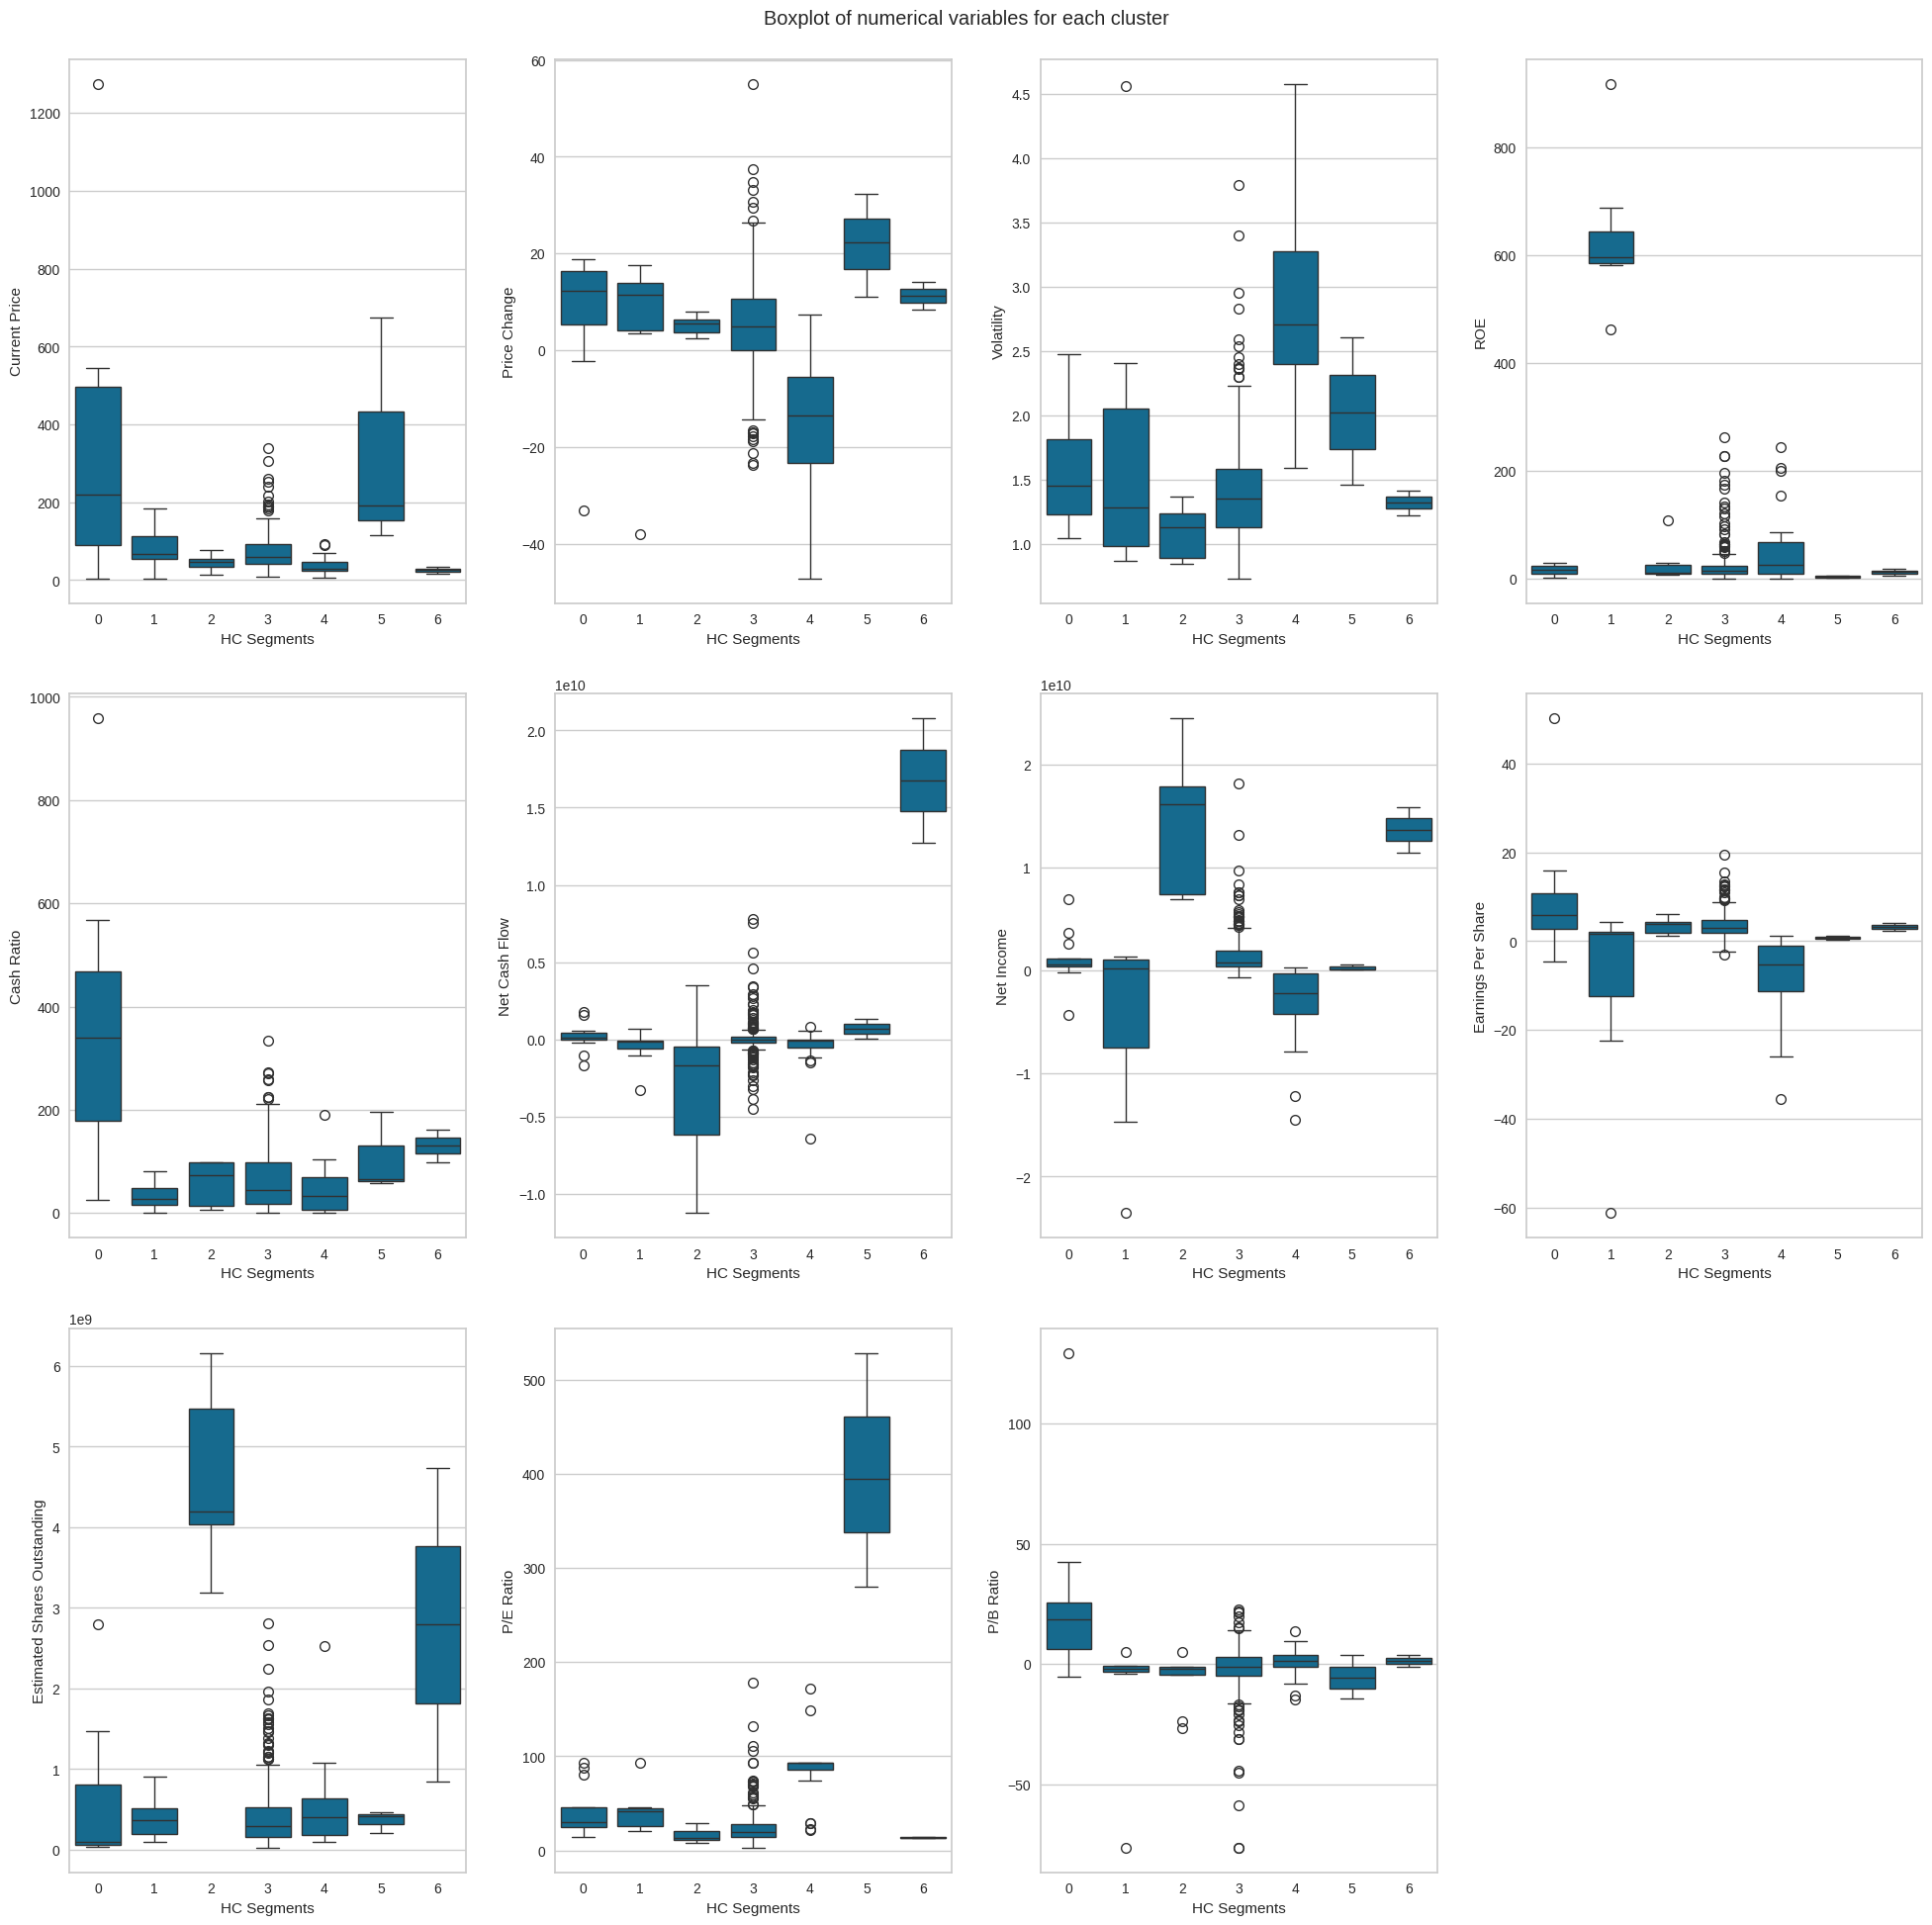

In [ ]:
# original dataframe
plt.figure(figsize=(20, 20))
plt.suptitle("Boxplot of numerical variables for each cluster")

for i, variable in enumerate(numeric_columns):
    plt.subplot(3, 4, i + 1)
    sns.boxplot(data=df2, x="HC Segments", y=variable)

plt.tight_layout(pad=2.0)

### Insights

- Cluster 0:
  - This cluster has a high current price.
  - This cluster has the highest cash ratio and earnings per share.
  - The volatility and price change is moderate.
  - Therefore, this cluster consists of high-valued, stable stocks.
- Cluster 1:
  - This cluster has the greatest ROE.
  - This cluster has negative net cash flow and income, indicating firm losses.
  - Based on this information, this cluster contains unprofitable companies with high-risk stocks.
- Cluster 2:
  - This cluster has the highest volatility.
  - The stocks in this cluster have negative net cash flow and income, indicating losses.
  - This cluster is characterized by high-risk, high-loss stocks.
- Cluster 3:
  - This cluster has a moderate average price, as well as cash ratio.
  - The stocks in this cluster also have the least price change.
  - This cluster is significantly larger than the others.
  - This cluster represents the baseline.
- Cluster 4:
  - The current price and price change is lower than the other clusters.
  - This cluster has the highest net income and estimated shares outstanding.
  - This indicates that this cluster consists of stocks of established companies with large shareholder bases.
- Cluster 5:
  - This cluster has the highest current price and price change.
  - Cash ratio and net cash flow are also high.
  - The average net income is lower than the other profit gaining clusters.
  - There are only 3 stocks in this cluster.
  - Based on these characteristics, this cluster consists of expensive, fast-growing outliers.
- Cluster 6:
 - This cluster has the highest net cash flow.
 - The size is only 2 segments.
 - This cluster consists of stocks of the highest profit-generating companies.

## K-means vs Hierarchical Clustering

You compare several things, like:
- Which clustering technique took less time for execution?
- Which clustering technique gave you more distinct clusters, or are they the same?
- How many observations are there in the similar clusters of both algorithms?
- How many clusters are obtained as the appropriate number of clusters from both algorithms?

You can also mention any differences or similarities you obtained in the cluster profiles from both the clustering techniques.

- Computation Comparison:
  - K-Means Clustering was less computationally expensive than Hierarchical Clustering.
  - K-Means Clustering was also less difficult and time-consuming.
- Cluster Comparison:
  - K-Means Clustering produced 4 clusters while Hierarchical Clustering produced 7 clusters.
  - While Hierarchical Clustering produced more distinct clusters, there were some clusters with only 2 or 3 instances.
  - On the other hand, K-Means Clustering created less clusters but allowed for more insightful interpretations of the data.
  - The final K-Means Clustering model was better suited for the data.
- Similarities:
  - Both clustering techniques produced clusters that shared similar traits. The clusters include a majority/baseline group, high-risk/high-loss group, and a fast-growing/premium group.

\
The K-Means Clusters are more general but just as insightful, better fitting the context of helping investors diversify their portfolios. The actionable insights and recommendations will be based on the K-Means Clusters.

## Actionable Insights and Recommendations

(Based on K-Means Clusters)
- Cluster 0 is composed of moderately priced, low-risk stocks that represent the market norm. From an investor standpoint, stocks within this cluster are core holdings that are best for long-term profit. Stocks within Cluster 0 are ideal for new buyers and risk-averse investors. All investors should consider investing in these stocks to build their portfolio.

- Cluster 1 contains undervalued, high-earning outliers. This group is characterized by low prices, high stability, and high profitability. Stocks within Cluster 0 are ideal for any kind of investor. The recommended action for all investors is to accumulate these stocks.

- Cluster 2 is made up of high-risk, unprofitable stocks. These stocks are volatile and have greater potential for losses, meaning most investors should avoid items within Cluster 2. Investors should be aware of the risk before buying. Since these stocks are less expensive and prone to change, there is opportunity for market speculation and short-term profit. Stocks within Cluster 2 are only recommended for risk-tolerant, short-term traders. Those that decide to buy should only engage in short-term trading.

- Cluster 3 represented high growth, premium value stocks. This cluster was the most expensive out of the four but yielded the highest price change and profitability. Stocks within this cluster are ideal for growth-oriented investors that are willing to pay premium price. Investors should buy these stocks on dips and hold for medium to long-term growth.